# Marketing Campaign Dataset - Combined Analysis

This notebook combines all marketing dataset analyses from Assignments 1-3.
- **Part 1**: Supervised Learning (Neural Network, SVM, KNN) — Assignment 1
- **Part 2**: Randomized Optimization (RHC, SA, GA for NN training) — Assignment 2
- **Part 3**: Unsupervised Learning (K-Means, EM, PCA, ICA, RP) + DR-enhanced NN — Assignment 3


---
# Part 1: Supervised Learning (Assignment 1)

Neural Network, SVM, and KNN on the marketing campaign dataset.


In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset
import time
from datetime import datetime
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score


In [2]:


marketing_file = "./dataset/marketing_campaign.csv"

marketing_df = pd.read_csv("./dataset/marketing_campaign.csv", sep='\t', encoding="ascii")


In [3]:
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
marketing_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
# Fill null values with median
marketing_df['Income'].fillna(marketing_df['Income'].median(), inplace=True)

In [6]:
# Dt_Customer ->datetime
marketing_df['Dt_Customer'] = pd.to_datetime(marketing_df['Dt_Customer'], format='%d-%m-%Y')

reference_date = datetime(2014, 7, 1)
marketing_df['Customer_Since_Months'] = (reference_date - marketing_df['Dt_Customer']).dt.days // 30

marketing_df.drop(columns=['Dt_Customer'], inplace=True)

In [7]:
print(marketing_df['Education'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Education'], drop_first=False)

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [8]:
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].replace({'Absurd': 'Other', 'YOLO': 'Other'})

print(marketing_df['Marital_Status'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Marital_Status'], drop_first=False)

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Other         4
Alone         3
Name: count, dtype: int64


In [9]:
marketing_df['Age'] = 2015 - marketing_df['Year_Birth']

marketing_df.drop(columns=['Year_Birth'], inplace=True)


In [10]:
irrelevant_columns = ['ID', 'NumDealsPurchases', 'Response']
marketing_df = marketing_df.drop(columns=irrelevant_columns)

In [11]:
marketing_df['AcceptedAny'] = (
    (marketing_df['AcceptedCmp1'] == 1) | 
    (marketing_df['AcceptedCmp2'] == 1) | 
    (marketing_df['AcceptedCmp3'] == 1) | 
    (marketing_df['AcceptedCmp4'] == 1) | 
    (marketing_df['AcceptedCmp5'] == 1)
).astype(int)

marketing_df.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], inplace=True)

print(marketing_df[['AcceptedAny']].value_counts())

AcceptedAny
0              1777
1               463
Name: count, dtype: int64


In [12]:
marketing_df['Education'] = marketing_df[['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD']].idxmax(axis=1)

marketing_df['Marital_Status'] = marketing_df[['Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 
                                               'Marital_Status_Divorced', 'Marital_Status_Widow', 'Marital_Status_Alone',
                                               'Marital_Status_Other']].idxmax(axis=1)
marketing_df.drop(columns=['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD',
                           'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 'Marital_Status_Divorced', 
                           'Marital_Status_Widow', 'Marital_Status_Alone', 'Marital_Status_Other'], inplace=True)

print(marketing_df[['Education', 'Marital_Status']].head())

              Education           Marital_Status
0  Education_Graduation    Marital_Status_Single
1  Education_Graduation    Marital_Status_Single
2  Education_Graduation  Marital_Status_Together
3  Education_Graduation  Marital_Status_Together
4         Education_PhD   Marital_Status_Married


In [13]:
marketing_df['Education'] = marketing_df['Education'].str.replace('Education_', '')
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].str.replace('Marital_Status_', '')

print(marketing_df[['Education', 'Marital_Status']].head())

    Education Marital_Status
0  Graduation         Single
1  Graduation         Single
2  Graduation       Together
3  Graduation       Together
4         PhD        Married


In [14]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
marketing_df['Education'] = label_enc.fit_transform(marketing_df['Education'])
marketing_df['Marital_Status'] = label_enc.fit_transform(marketing_df['Marital_Status'])

print(marketing_df[['Education', 'Marital_Status']].value_counts())

Education  Marital_Status
2          2                 433
           5                 286
           4                 252
4          2                 192
3          2                 138
2          1                 119
4          5                 117
3          5                 106
4          4                  98
0          2                  81
3          4                  75
0          5                  57
4          1                  52
0          4                  37
3          1                  37
2          6                  35
4          6                  24
0          1                  23
1          2                  20
           4                  18
           5                  14
3          6                  12
0          6                   5
4          3                   2
2          0                   1
1          6                   1
           1                   1
2          3                   1
3          0                   1
           3     

In [15]:
def split_data(marketing_df, method='train_val_test', k=5, val_size=0.2, test_size=0.2):
    
    X = marketing_df.drop(columns=['AcceptedAny']).values
    y = marketing_df['AcceptedAny'].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if method == 'train_val_test':
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        val_size_adjusted = val_size / (1 - test_size) 
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size_adjusted, random_state=42, stratify=y_train_val
        )

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

        print(f"Train: {X_train_tensor.shape[0]}, Val: {X_val_tensor.shape[0]}, Test: {X_test_tensor.shape[0]}")
        return X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor

    elif method == 'cross_val':
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        folds = []

        for train_index, test_index in skf.split(X, y):
            X_train_fold, X_test_fold = X[train_index], X[test_index]
            y_train_fold, y_test_fold = y[train_index], y[test_index]

            X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
            X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).unsqueeze(1)

            folds.append((X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor))

        print(f"Train: {folds[0][0].shape[0]}, Test: {folds[0][2].shape[0]}")
        return folds


In [16]:
# Simple Split
X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')


Train: 1344, Val: 448, Test: 448


In [50]:
class SimpleNN(nn.Module):
    def __init__(self, activation_function=nn.ReLU()):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            activation_function,
            nn.Linear(64, 32),
            activation_function,
            nn.Linear(32, 16),
            activation_function,
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [168]:
num_epochs = 300
batch_size = 64
learning_rate = 0.001

In [169]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)




In [170]:

val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [171]:
def train_model(model, train_loader, val_loader, test_loader, num_epochs=200, lr=0.001):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    criterion = nn.BCELoss()
    train_losses, val_losses, test_losses = [], [], []
    best_model = None
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        train_losses.append(epoch_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                test_loss += loss.item()
        test_loss /= len(test_loader)
        test_losses.append(test_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()

        if best_model:
            torch.save(best_model, "best_model.pth")

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}")

    plt.figure(figsize=(10, 5))
    plt.title('Learning Curve - Neural Network: Loss/Error Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
    plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
    plt.legend()
    # plt.savefig("loss_all_full_nn_300epoch_400data.png")
    plt.show()
    
    

    return train_losses, val_losses, test_losses


Epoch 1/300 - Train Loss: 0.7707, Val Loss: 0.7554, Test Loss: 0.7557
Epoch 2/300 - Train Loss: 0.7393, Val Loss: 0.7211, Test Loss: 0.7217
Epoch 3/300 - Train Loss: 0.7073, Val Loss: 0.6905, Test Loss: 0.6914
Epoch 4/300 - Train Loss: 0.6789, Val Loss: 0.6653, Test Loss: 0.6663
Epoch 5/300 - Train Loss: 0.6555, Val Loss: 0.6427, Test Loss: 0.6440
Epoch 6/300 - Train Loss: 0.6347, Val Loss: 0.6237, Test Loss: 0.6251
Epoch 7/300 - Train Loss: 0.6168, Val Loss: 0.6069, Test Loss: 0.6084
Epoch 8/300 - Train Loss: 0.6008, Val Loss: 0.5923, Test Loss: 0.5939
Epoch 9/300 - Train Loss: 0.5870, Val Loss: 0.5787, Test Loss: 0.5804
Epoch 10/300 - Train Loss: 0.5741, Val Loss: 0.5672, Test Loss: 0.5692
Epoch 11/300 - Train Loss: 0.5633, Val Loss: 0.5561, Test Loss: 0.5583
Epoch 12/300 - Train Loss: 0.5531, Val Loss: 0.5465, Test Loss: 0.5490
Epoch 13/300 - Train Loss: 0.5441, Val Loss: 0.5379, Test Loss: 0.5407
Epoch 14/300 - Train Loss: 0.5362, Val Loss: 0.5299, Test Loss: 0.5330
Epoch 15/300 - 

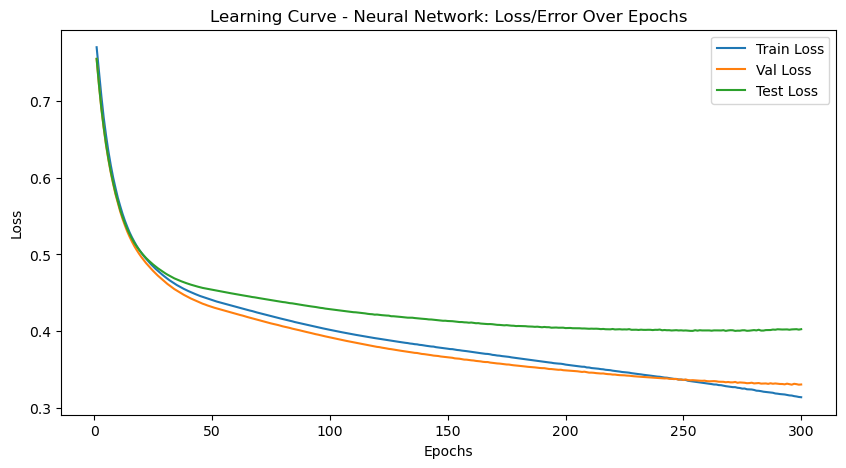

Training Time: 17.19


In [172]:
model = SimpleNN(activation_function=nn.ReLU())
start_time = time.time()
train_losses, val_losses, test_losses = train_model(model, train_loader, val_loader, test_loader, num_epochs=num_epochs, lr=0.001)
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f}")

In [164]:
# test_losses_list = [test_losses_01, test_losses_001, test_losses_0001]

In [165]:
# training time
training_time_nn = [[6.24, 100], [17.64, 300],[30.20, 500]]


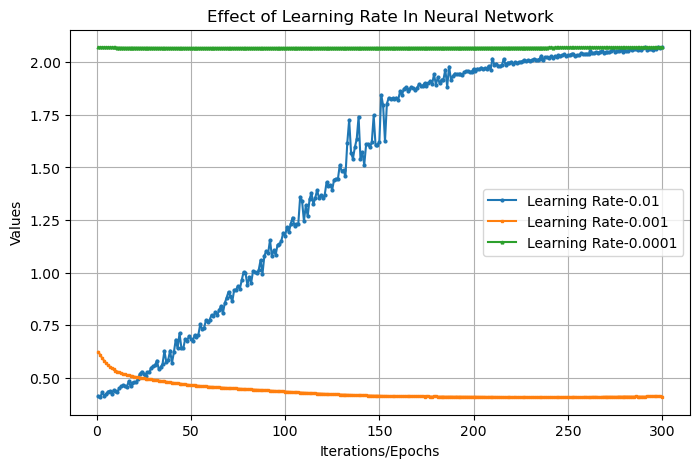

In [167]:
# x = np.arange(1, 301)


# # Plotting
# plt.figure(figsize=(8, 5))
# plt.title("Effect of Learning Rate In Neural Network")
# plt.xlabel("Iterations/Epochs")
# plt.ylabel("Values")
# plt.plot(x, test_losses_list[0], label="Learning Rate-0.01", linestyle="-", marker="o", markersize=2)
# plt.plot(x, test_losses_list[1], label="Learning Rate-0.001", linestyle="-", marker="s", markersize=2)
# plt.plot(x, test_losses_list[2], label="Learning Rate-0.0001", linestyle="-", marker="^", markersize=2)
# plt.legend()
# plt.savefig("nn_lr.png")
# plt.grid(True)

# # Show the plot
# plt.show()

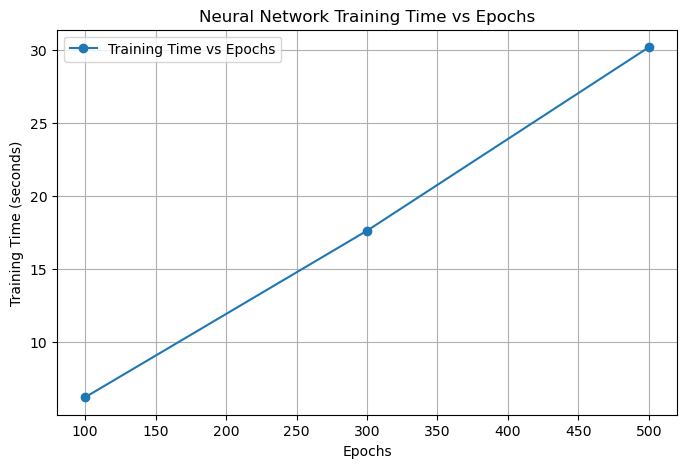

In [178]:

epochs = [item[1] for item in training_time_nn]
training_times = [item[0] for item in training_time_nn]

plt.figure(figsize=(8, 5)) 
plt.title("Neural Network Training Time vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Training Time (seconds)")
plt.plot(epochs, training_times, marker='o', linestyle='-', label="Training Time vs Epochs")
plt.legend()
plt.grid(True)
plt.savefig("nn_training_time.png") 
plt.show()

In [173]:

def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            predictions = (outputs > 0.5).float() 
            y_true.extend(y_batch.numpy())
            y_pred.extend(predictions.numpy())

    return y_true, y_pred

In [174]:
y_true, y_pred = evaluate_model(model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.83
F1-Score: 0.51
Precision: 0.64
Recall: 0.42


In [180]:
folds = split_data(marketing_df, method='cross_val', k=5)

Train: 1792, Test: 448


In [188]:

def cross_val_evaluate(model_class, folds, num_epochs=300, lr=0.001, batch_size=64):
    fold_accuracies, fold_f1_scores, fold_precisions, fold_recalls = [], [], [], []
    total_training_time = 0

    for fold_idx, (X_train, y_train, X_test, y_test) in enumerate(folds):
        print(f"=== Fold {fold_idx + 1} ===")
        
        train_dataset = TensorDataset(X_train, y_train)
        test_dataset = TensorDataset(X_test, y_test)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model = model_class()
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
        criterion = nn.BCELoss()

        start_time = time.time()

        for epoch in range(num_epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()

        end_time = time.time()
        total_training_time += (end_time - start_time)

        y_true, y_pred = [], []
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                predictions = (outputs > 0.5).float()
                y_true.extend(y_batch.numpy())
                y_pred.extend(predictions.numpy())

        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)

        fold_accuracies.append(accuracy)
        fold_f1_scores.append(f1)
        fold_precisions.append(precision)
        fold_recalls.append(recall)


    print(f"Average Accuracy: {sum(fold_accuracies) / len(fold_accuracies):.2f}")
    print(f"Average F1-Score: {sum(fold_f1_scores) / len(fold_f1_scores):.2f}")
    print(f"Average Precision: {sum(fold_precisions) / len(fold_precisions):.2f}")
    print(f"Average Recall: {sum(fold_recalls) / len(fold_recalls):.2f}")
    print(f"Total Training Time: {total_training_time:.2f} seconds")

In [189]:
cross_val_evaluate(SimpleNN, folds, num_epochs=300, lr=0.001, batch_size=64)

=== Fold 1 ===
=== Fold 2 ===
=== Fold 3 ===
=== Fold 4 ===
=== Fold 5 ===
Average Accuracy: 0.84
Average F1-Score: 0.56
Average Precision: 0.67
Average Recall: 0.48
Total Training Time: 73.16 seconds


In [17]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: 1344, Val: 448, Test: 448


In [18]:
from sklearn.svm import SVC


In [19]:
svm_model = SVC(kernel='rbf', C=1000, probability=True) 

start_time = time.time()
svm_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()

svm_training_time = end_time - start_time


In [23]:
y_val_pred = svm_model.predict(X_val_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"SVM Accuracy: {accuracy:.2f}")
print(f"SVM F1-Score: {f1:.2f}")
print(f"SVM Precision: {precision:.2f}")
print(f"SVM Recall: {recall:.2f}")
print(f"SVM Training Time: {svm_training_time:.2f} seconds")

SVM Accuracy: 0.79
SVM F1-Score: 0.45
SVM Precision: 0.49
SVM Recall: 0.42
SVM Training Time: 0.83 seconds



Training SVM with 400 samples
Training Error: 0.00
Testing Error: 0.21

Training SVM with 800 samples
Training Error: 0.00
Testing Error: 0.19

Training SVM with 1344 samples
Training Error: 0.01
Testing Error: 0.17


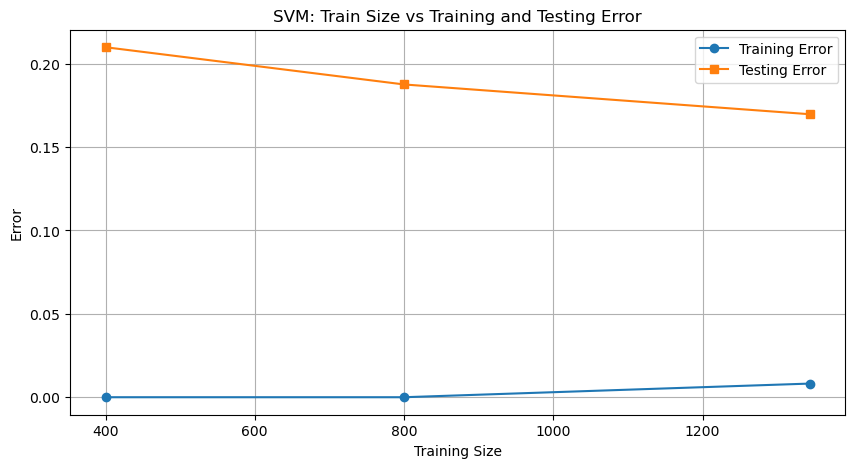

In [24]:
train_sizes = [400, 800, 1344]
svm_results = []

for size in train_sizes:
    print(f"\nTraining SVM with {size} samples")
    
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    svm_model = SVC(kernel='rbf', C=100, probability=True)  # Best hyperparameters
    svm_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = svm_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = svm_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    svm_results.append((size, train_error, test_error))

    print(f"Training Error: {train_error:.2f}")
    print(f"Testing Error: {test_error:.2f}")

svm_results = np.array(svm_results)

plt.figure(figsize=(10, 5))
plt.title("SVM: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(svm_results[:, 0], svm_results[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(svm_results[:, 0], svm_results[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("svm_train_size_vs_error.png")
plt.show()


Training SVM with 400 samples
SVM Accuracy: 0.79
SVM F1-Score: 0.45
SVM Precision: 0.49
SVM Recall: 0.42
SVM Training Time: 0.72 seconds

Training SVM with 800 samples
SVM Accuracy: 0.81
SVM F1-Score: 0.56
SVM Precision: 0.55
SVM Recall: 0.58
SVM Training Time: 0.72 seconds

Training SVM with 1344 samples
SVM Accuracy: 0.83
SVM F1-Score: 0.56
SVM Precision: 0.60
SVM Recall: 0.53
SVM Training Time: 0.72 seconds


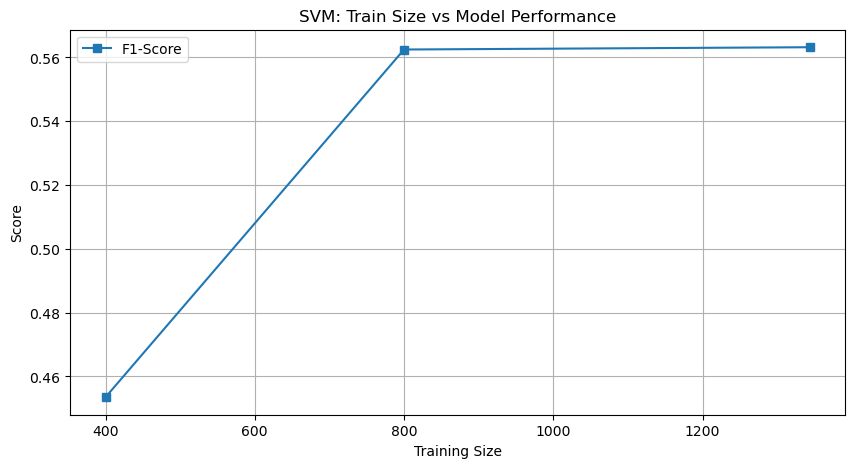

In [213]:
train_sizes = [400, 800, 1344]
svm_results = []


for size in train_sizes:
    print(f"\nTraining SVM with {size} samples")
    
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    svm_model = SVC(kernel='rbf', C=100, probability=True) # best hyperparameters
    svm_model.fit(X_train_subset, y_train_subset.ravel())

    y_test_pred = svm_model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)

    svm_results.append((size, accuracy, f1, precision, recall, training_time))

    print(f"SVM Accuracy: {accuracy:.2f}")
    print(f"SVM F1-Score: {f1:.2f}")
    print(f"SVM Precision: {precision:.2f}")
    print(f"SVM Recall: {recall:.2f}")
    print(f"SVM Training Time: {training_time:.2f} seconds")

svm_results = np.array(svm_results)

plt.figure(figsize=(10, 5))
plt.title("SVM: Train Size vs Model Performance")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.plot(svm_results[:, 0], svm_results[:, 2], marker='s', linestyle='-', label="F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("svm_train_size_vs_performance.png")
plt.show()

# KNN

In [25]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time

X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



Train: 1344, Val: 448, Test: 448


In [26]:

k_values = [3, 5, 7, 9]
distance_metrics = ['manhattan', 'euclidean']
results = []

for k in k_values:
    for metric in distance_metrics:
        knn_model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        start_time = time.time()
        knn_model.fit(X_train_scaled, y_train)
        end_time = time.time()
        training_time = end_time - start_time

        y_val_pred = knn_model.predict(X_val_scaled)
        val_f1 = f1_score(y_val, y_val_pred)

        results.append({
            'k': k,
            'metric': metric,
            'val_f1': val_f1,
            'training_time': training_time
        })

print("{:<10} {:<15} {:<10} {:<15}".format("K", "Distance Metric", "F1-Score", "Training Time (s)"))
for result in results:
    print("{:<10} {:<15} {:<10.4f} {:<15.2f}".format(result['k'], result['metric'], result['val_f1'], result['training_time']))

best_result = max(results, key=lambda x: x['val_f1'])
print("\nBest Parameters:")
print(f"K: {best_result['k']}, Distance Metric: {best_result['metric']}, F1-Score: {best_result['val_f1']:.4f}, Training Time: {best_result['training_time']:.2f} seconds")

K          Distance Metric F1-Score   Training Time (s)
3          manhattan       0.5369     0.00           
3          euclidean       0.5385     0.00           
5          manhattan       0.5143     0.00           
5          euclidean       0.5241     0.00           
7          manhattan       0.4741     0.00           
7          euclidean       0.4341     0.00           
9          manhattan       0.4511     0.00           
9          euclidean       0.4496     0.00           

Best Parameters:
K: 3, Distance Metric: euclidean, F1-Score: 0.5385, Training Time: 0.00 seconds


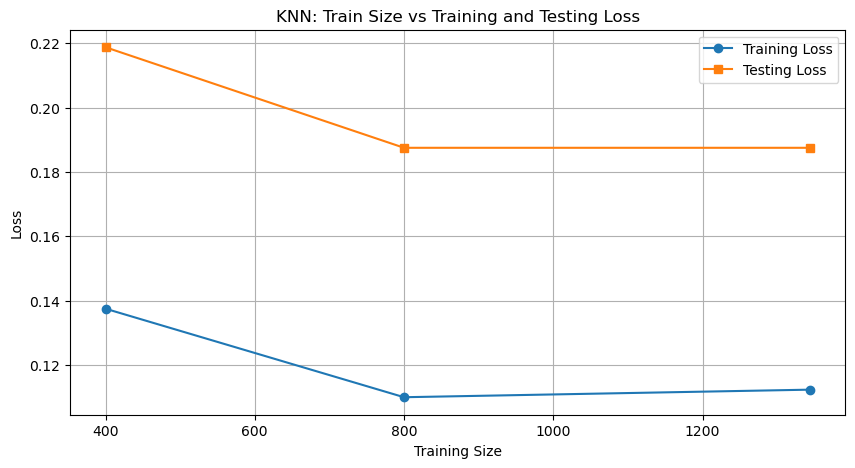

In [27]:
train_sizes = [400, 800, 1344]
results = []

for size in train_sizes:
    X_train_partial = X_train_scaled[:size]
    y_train_partial = y_train[:size]

    knn_model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

    start_time = time.time()
    knn_model.fit(X_train_partial, y_train_partial)
    end_time = time.time()
    training_time = end_time - start_time

    y_train_pred = knn_model.predict(X_train_partial)
    y_test_pred = knn_model.predict(X_test_scaled)

    train_loss = 1 - accuracy_score(y_train_partial, y_train_pred)
    test_loss = 1 - accuracy_score(y_test, y_test_pred)

    results.append({'train_size': size, 'train_loss': train_loss, 'test_loss': test_loss})

train_sizes = [r['train_size'] for r in results]
train_losses = [r['train_loss'] for r in results]
test_losses = [r['test_loss'] for r in results]

# Plot
plt.figure(figsize=(10, 5))
plt.title("KNN: Train Size vs Training and Testing Loss")
plt.xlabel("Training Size")
plt.ylabel("Loss")
plt.plot(train_sizes, train_losses, marker='o', linestyle='-', label="Training Loss")
plt.plot(train_sizes, test_losses, marker='s', linestyle='-', label="Testing Loss")
plt.legend()
plt.grid(True)
plt.savefig("knn_train_size_vs_loss.png")
plt.show()

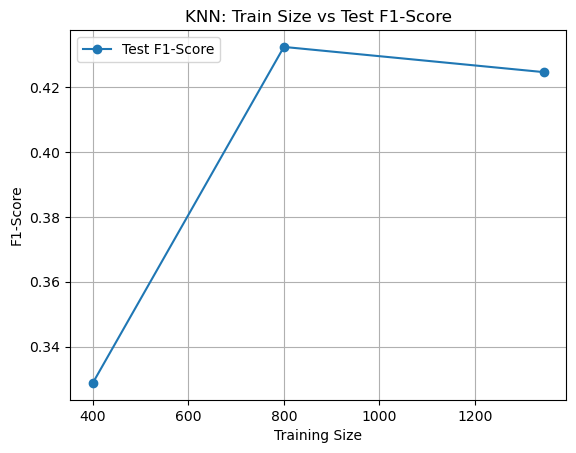

In [218]:
train_sizes = [400, 800, 1344]
results = []

for size in train_sizes:
    X_train_partial = X_train_scaled[:size]
    y_train_partial = y_train[:size]

    knn_model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
    
    start_time = time.time()
    knn_model.fit(X_train_partial, y_train_partial)
    end_time = time.time()
    training_time = end_time - start_time

    y_val_pred = knn_model.predict(X_val_scaled)
    y_test_pred = knn_model.predict(X_test_scaled)

    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)

    results.append({'train_size': size,'test_f1': test_f1,})

train_sizes = [r['train_size'] for r in results]
test_f1_scores = [r['test_f1'] for r in results]

plt.title("KNN: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot(train_sizes, test_f1_scores, marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("knn_train_size_vs_f1.png")
plt.show()

---
# Part 2: Randomized Optimization (Assignment 2)

Using Random Hill Climbing (RHC), Simulated Annealing (SA), and Genetic Algorithm (GA) 
to train Neural Network weights on the marketing campaign dataset, compared with SGD.

*(K-Coloring and TSP optimization problems are excluded as they are not related to the marketing dataset.)*


In [4]:
!pip install joblib==1.2.0

In [2]:
!pip install mlrose-hiive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mlrose-hiive: filename=mlrose_hiive-2.2.4-py3-none-any.whl size=98335 sha256=29ebf3a84a2ecab711c7fa66775cd7e83f0d99c218182802b26b7398e9e50d21
  Stored in directory: /root/.cache/pip/wheels/7d/37/ec/8f4f01ed6712f4784ba7bcb6c666a6a20e0c31901bb8c6578d
Successfully built mlrose-hiive


In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset
import time
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score


In [5]:
import mlrose_hiive as mlrose

In [6]:
np.random.seed(42) # random seed

In [50]:
marketing_file = "./dataset/marketing_campaign.csv"
marketing_df = pd.read_csv("./dataset/marketing_campaign.csv", sep='\t', encoding="ascii")

marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [51]:
marketing_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [52]:
# Fill null values with median
marketing_df['Income'].fillna(marketing_df['Income'].median(), inplace=True)

In [53]:
# Dt_Customer ->datetime
marketing_df['Dt_Customer'] = pd.to_datetime(marketing_df['Dt_Customer'], format='%d-%m-%Y')

reference_date = datetime(2014, 7, 1)
marketing_df['Customer_Since_Months'] = (reference_date - marketing_df['Dt_Customer']).dt.days // 30

marketing_df.drop(columns=['Dt_Customer'], inplace=True)

print(marketing_df['Education'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Education'], drop_first=False)

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [54]:
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].replace({'Absurd': 'Other', 'YOLO': 'Other'})

print(marketing_df['Marital_Status'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Marital_Status'], drop_first=False)

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Other         4
Alone         3
Name: count, dtype: int64


In [55]:
marketing_df['Age'] = 2015 - marketing_df['Year_Birth']

marketing_df.drop(columns=['Year_Birth'], inplace=True)

irrelevant_columns = ['ID', 'NumDealsPurchases', 'Response']
marketing_df = marketing_df.drop(columns=irrelevant_columns)

marketing_df['AcceptedAny'] = (
    (marketing_df['AcceptedCmp1'] == 1) |
    (marketing_df['AcceptedCmp2'] == 1) |
    (marketing_df['AcceptedCmp3'] == 1) |
    (marketing_df['AcceptedCmp4'] == 1) |
    (marketing_df['AcceptedCmp5'] == 1)
).astype(int)

marketing_df.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], inplace=True)

print(marketing_df[['AcceptedAny']].value_counts())

marketing_df['Education'] = marketing_df[['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD']].idxmax(axis=1)

marketing_df['Marital_Status'] = marketing_df[['Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married',
                                               'Marital_Status_Divorced', 'Marital_Status_Widow', 'Marital_Status_Alone',
                                               'Marital_Status_Other']].idxmax(axis=1)
marketing_df.drop(columns=['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD',
                           'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 'Marital_Status_Divorced',
                           'Marital_Status_Widow', 'Marital_Status_Alone', 'Marital_Status_Other'], inplace=True)

print(marketing_df[['Education', 'Marital_Status']].head())

AcceptedAny
0              1777
1               463
Name: count, dtype: int64
              Education           Marital_Status
0  Education_Graduation    Marital_Status_Single
1  Education_Graduation    Marital_Status_Single
2  Education_Graduation  Marital_Status_Together
3  Education_Graduation  Marital_Status_Together
4         Education_PhD   Marital_Status_Married


In [56]:
marketing_df['Education'] = marketing_df['Education'].str.replace('Education_', '')
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].str.replace('Marital_Status_', '')

print(marketing_df[['Education', 'Marital_Status']].head())

    Education Marital_Status
0  Graduation         Single
1  Graduation         Single
2  Graduation       Together
3  Graduation       Together
4         PhD        Married


In [57]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
marketing_df['Education'] = label_enc.fit_transform(marketing_df['Education'])
marketing_df['Marital_Status'] = label_enc.fit_transform(marketing_df['Marital_Status'])

print(marketing_df[['Education', 'Marital_Status']].value_counts())

Education  Marital_Status
2          2                 433
           5                 286
           4                 252
4          2                 192
3          2                 138
2          1                 119
4          5                 117
3          5                 106
4          4                  98
0          2                  81
3          4                  75
0          5                  57
4          1                  52
0          4                  37
3          1                  37
2          6                  35
4          6                  24
0          1                  23
1          2                  20
           4                  18
           5                  14
3          6                  12
0          6                   5
4          3                   2
3          0                   1
2          3                   1
           0                   1
3          3                   1
1          6                   1
4          0     

In [60]:
def split_data(marketing_df, method='train_val_test', k=5, val_size=0.2, test_size=0.2):

    X = marketing_df.drop(columns=['AcceptedAny']).values
    y = marketing_df['AcceptedAny'].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if method == 'train_val_test':
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        val_size_adjusted = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size_adjusted, random_state=42, stratify=y_train_val
        )

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

        print(f"Train: {X_train_tensor.shape[0]}, Val: {X_val_tensor.shape[0]}, Test: {X_test_tensor.shape[0]}")
        return X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor

    elif method == 'cross_val':
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        folds = []

        for train_index, test_index in skf.split(X, y):
            X_train_fold, X_test_fold = X[train_index], X[test_index]
            y_train_fold, y_test_fold = y[train_index], y[test_index]

            X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
            X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).unsqueeze(1)

            folds.append((X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor))

        print(f"Train: {folds[0][0].shape[0]}, Test: {folds[0][2].shape[0]}")
        return folds


In [59]:
# Simple Split
X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')


Train: 1344, Val: 448, Test: 448


In [61]:
class SimpleNN(nn.Module):
    def __init__(self, activation_function=nn.ReLU()):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            activation_function,
            nn.Linear(64, 32),
            activation_function,
            nn.Linear(32, 16),
            activation_function,
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [62]:
num_epochs = 300
batch_size = 64
learning_rate = 0.001

In [63]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)



val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [77]:
def train_model(model, train_loader, val_loader, test_loader, num_epochs=200, lr=0.001):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    criterion = nn.BCELoss()
    train_losses, val_losses, test_losses = [], [], []
    best_model = None
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        train_losses.append(epoch_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                test_loss += loss.item()
        test_loss /= len(test_loader)
        test_losses.append(test_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()

        if best_model:
            torch.save(best_model, "best_model.pth")

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}")

    plt.figure(figsize=(10, 5))
    plt.title('Learning Curve - Neural Network: Loss/Error Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
    plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
    plt.legend()
    plt.savefig("loss_all_full_nn_300epoch.png")
    plt.show()



    return train_losses, -train_losses[-1]


In [73]:
model_ro = SimpleNN(activation_function=nn.ReLU())


In [74]:
def get_weights(model):
    return np.concatenate([param.detach().cpu().numpy().flatten() for param in model.parameters()])

def set_weights(model, flat_weights):
    pointer = 0
    for param in model.parameters():
        num_param = param.numel()
        new_weights = flat_weights[pointer:pointer+num_param].reshape(param.shape)
        param.data = torch.tensor(new_weights, dtype=param.data.dtype, device=param.data.device)
        pointer += num_param

def fitness_function(weights):
    set_weights(model_ro, weights)
    model_ro.eval()
    criterion = nn.BCELoss()
    with torch.no_grad():
        outputs = model_ro(X_train)
        loss = criterion(outputs, y_train).item()
    return -loss

In [75]:
def train_with_RO(algorithm, max_iters=300, max_attempts=100):
    init_weights = get_weights(model_ro)
    fitness = mlrose.CustomFitness(fitness_function)
    problem = mlrose.ContinuousOpt(length=len(init_weights), fitness_fn=fitness, maximize=True, max_val=1, min_val=-1)

    if algorithm == "RHC":
        best_weights, best_fitness, fitness_curve = mlrose.random_hill_climb(
            problem, max_iters=max_iters, max_attempts=max_attempts, curve=True, random_state=42)
    elif algorithm == "SA":
        schedule = mlrose.GeomDecay(init_temp=1.0, decay=0.95, min_temp=0.001)
        best_weights, best_fitness, fitness_curve = mlrose.simulated_annealing(
            problem, schedule=schedule, max_iters=max_iters, max_attempts=max_attempts, curve=True, random_state=42)
    elif algorithm == "GA":
        best_weights, best_fitness, fitness_curve = mlrose.genetic_alg(
            problem, pop_size=200, mutation_prob=0.1, max_iters=max_iters, max_attempts=max_attempts, curve=True, random_state=42)
    else:
        raise ValueError("Invalid algorithm")
    return best_weights, best_fitness, fitness_curve

Epoch 1/300 - Train Loss: 0.7476, Val Loss: 0.7361, Test Loss: 0.7361
Epoch 2/300 - Train Loss: 0.7236, Val Loss: 0.7092, Test Loss: 0.7094
Epoch 3/300 - Train Loss: 0.6975, Val Loss: 0.6844, Test Loss: 0.6847
Epoch 4/300 - Train Loss: 0.6741, Val Loss: 0.6614, Test Loss: 0.6619
Epoch 5/300 - Train Loss: 0.6525, Val Loss: 0.6414, Test Loss: 0.6421
Epoch 6/300 - Train Loss: 0.6333, Val Loss: 0.6236, Test Loss: 0.6244
Epoch 7/300 - Train Loss: 0.6165, Val Loss: 0.6070, Test Loss: 0.6080
Epoch 8/300 - Train Loss: 0.6012, Val Loss: 0.5921, Test Loss: 0.5932
Epoch 9/300 - Train Loss: 0.5871, Val Loss: 0.5794, Test Loss: 0.5806
Epoch 10/300 - Train Loss: 0.5751, Val Loss: 0.5676, Test Loss: 0.5690
Epoch 11/300 - Train Loss: 0.5641, Val Loss: 0.5573, Test Loss: 0.5589
Epoch 12/300 - Train Loss: 0.5545, Val Loss: 0.5480, Test Loss: 0.5497
Epoch 13/300 - Train Loss: 0.5457, Val Loss: 0.5401, Test Loss: 0.5420
Epoch 14/300 - Train Loss: 0.5382, Val Loss: 0.5331, Test Loss: 0.5352
Epoch 15/300 - 

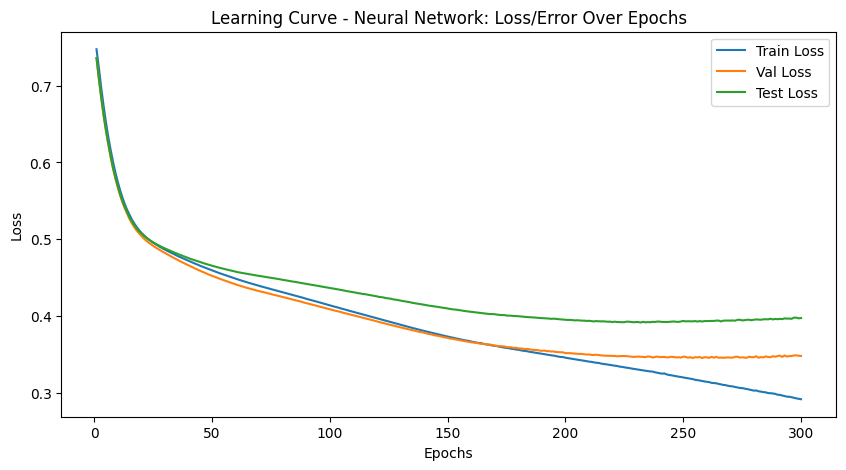

In [78]:
model_sgd = SimpleNN(activation_function=nn.ReLU())
start_time = time.time()
sgd_losses, sgd_fitness = train_model(model_sgd, train_loader, val_loader, test_loader, num_epochs=num_epochs, lr=0.001)

end_time = time.time()
training_time = end_time - start_time



RHC - Final Fitness: -8.7439, Time: 0.4170s
SA - Final Fitness: -9.5862, Time: 0.5872s
GA - Final Fitness: -1.6517, Time: 97.4481s


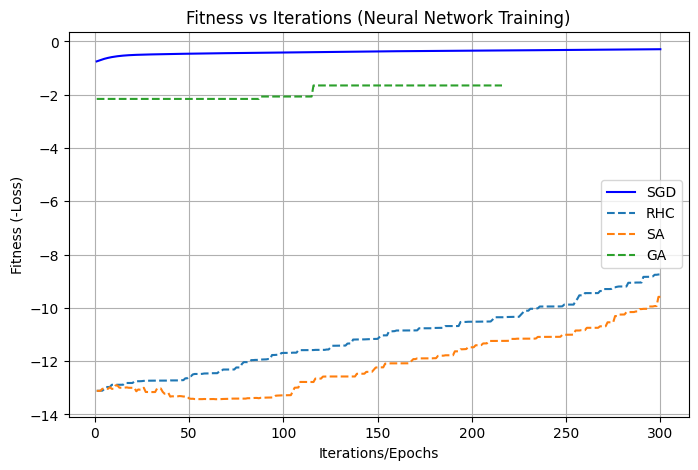

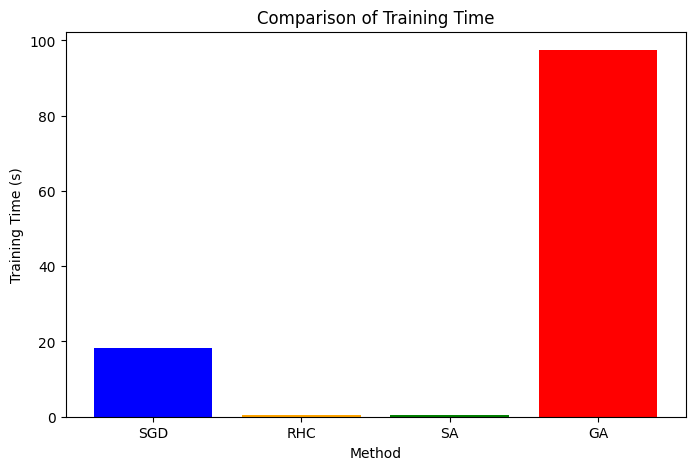

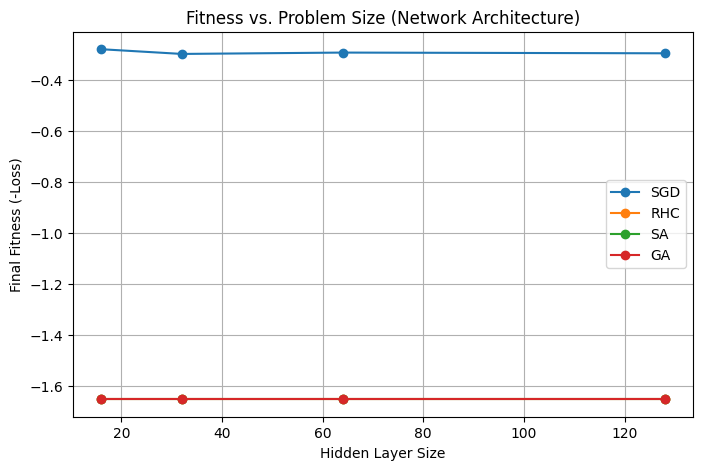

In [82]:
ro_algorithms = ["RHC", "SA", "GA"]
ro_results = {}
for algo in ro_algorithms:
    model_ro = SimpleNN(activation_function=nn.ReLU())
    start = time.time()
    best_w, best_fit, fitness_curve = train_with_RO(algo, max_iters=300, max_attempts=100)
    elapsed = time.time() - start
    ro_results[algo] = {"fitness_curve": fitness_curve[:, 0], "time": elapsed, "final_fitness": best_fit}
    print(f"{algo} - Final Fitness: {best_fit:.4f}, Time: {elapsed:.4f}s")

plt.figure(figsize=(8,5))
iterations = np.arange(1, 301)
plt.plot(iterations, -np.array(sgd_losses), label='SGD', color='blue', linestyle='-')
for algo in ro_algorithms:
    plt.plot(range(1, len(ro_results[algo]["fitness_curve"])+1), ro_results[algo]["fitness_curve"], label=algo, linestyle='--')
plt.xlabel("Iterations/Epochs")
plt.ylabel("Fitness (-Loss)")
plt.title("Fitness vs Iterations (Neural Network Training)")
plt.legend()
plt.grid()
plt.savefig("nn_fitness_vs_iterations.png", dpi=300, bbox_inches="tight")
plt.show()

methods = ['SGD'] + ro_algorithms
times = [training_time] + [ro_results[algo]["time"] for algo in ro_algorithms]
plt.figure(figsize=(8,5))
plt.bar(methods, times, color=['blue', 'orange', 'green', 'red'])
plt.xlabel("Method")
plt.ylabel("Training Time (s)")
plt.title("Comparison of Training Time")
plt.savefig("nn_training_time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

hidden_sizes = [16, 32, 64, 128]
sgd_fitness_vs_size = {}
ro_fitness_vs_size = {algo: {} for algo in ro_algorithms}

for size in hidden_sizes:
    model_temp = SimpleNN(activation_function=nn.ReLU())
    optimizer = optim.SGD(model_temp.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    criterion = nn.BCELoss()
    losses = []
    for epoch in range(300):
        model_temp.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model_temp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
    sgd_fitness_vs_size[size] = -losses[-1]

    for algo in ro_algorithms:
        model_ro = SimpleNN(activation_function=nn.ReLU())
        init_weights = get_weights(model_ro)

        def fitness_nn(w):
            set_weights(model_ro, w)
            model_ro.eval()
            with torch.no_grad():
                outputs = model_ro(X_train)
                loss = criterion(outputs, y_train).item()
            return -loss
        fitness = mlrose.CustomFitness(fitness_nn)
        problem = mlrose.ContinuousOpt(length=len(init_weights), fitness_fn=fitness, maximize=True, max_val=1, min_val=-1)
        best_w, best_fit, _ = mlrose.genetic_alg(problem, max_iters=300, pop_size=200, mutation_prob=0.1, max_attempts=100, random_state=42)
        ro_fitness_vs_size[algo][size] = best_fit

plt.figure(figsize=(8,5))
plt.plot(hidden_sizes, [sgd_fitness_vs_size[size] for size in hidden_sizes], marker='o', label='SGD')
for algo in ro_algorithms:
    plt.plot(hidden_sizes, [ro_fitness_vs_size[algo][size] for size in hidden_sizes], marker='o', label=algo)
plt.xlabel("Hidden Layer Size")
plt.ylabel("Final Fitness (-Loss)")
plt.title("Fitness vs. Problem Size (Network Architecture)")
plt.legend()
plt.grid()
plt.savefig("nn_fitness_vs_size.png", dpi=300, bbox_inches="tight")
plt.show()

---
# Part 3: Unsupervised Learning (Assignment 3)

K-Means clustering, Expectation Maximization (EM/GMM), PCA, ICA, Random Projection,
and Neural Network training with dimensionality reduction and cluster features
on the marketing campaign dataset.


In [1]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset
import time
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score


In [20]:


marketing_file = "./dataset/marketing_campaign.csv"

marketing_df = pd.read_csv("./dataset/marketing_campaign.csv", sep='\t', encoding="ascii")


In [38]:
marketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2240 non-null   float64
 1   Kidhome                  2240 non-null   int64  
 2   Teenhome                 2240 non-null   int64  
 3   Recency                  2240 non-null   int64  
 4   MntWines                 2240 non-null   int64  
 5   MntFruits                2240 non-null   int64  
 6   MntMeatProducts          2240 non-null   int64  
 7   MntFishProducts          2240 non-null   int64  
 8   MntSweetProducts         2240 non-null   int64  
 9   MntGoldProds             2240 non-null   int64  
 10  NumDealsPurchases        2240 non-null   int64  
 11  NumWebPurchases          2240 non-null   int64  
 12  NumCatalogPurchases      2240 non-null   int64  
 13  NumStorePurchases        2240 non-null   int64  
 14  NumWebVisitsMonth       

In [22]:
marketing_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [23]:
# Fill null values with median
marketing_df['Income'] = marketing_df['Income'].fillna(marketing_df['Income'].median())

In [24]:
# Dt_Customer ->datetime
marketing_df['Dt_Customer'] = pd.to_datetime(marketing_df['Dt_Customer'], format='%d-%m-%Y')

reference_date = datetime(2014, 7, 1)
marketing_df['Customer_Since_Months'] = (reference_date - marketing_df['Dt_Customer']).dt.days // 30

marketing_df.drop(columns=['Dt_Customer'], inplace=True)

In [25]:
print(marketing_df['Education'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Education'], drop_first=False)

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [26]:
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].replace({'Absurd': 'Other', 'YOLO': 'Other'})

print(marketing_df['Marital_Status'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Marital_Status'], drop_first=False)

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Other         4
Alone         3
Name: count, dtype: int64


In [27]:
marketing_df['Age'] = 2015 - marketing_df['Year_Birth']

marketing_df.drop(columns=['Year_Birth'], inplace=True)


In [28]:
irrelevant_columns = ['ID']
marketing_df = marketing_df.drop(columns=irrelevant_columns)

In [29]:

features = marketing_df.columns
scaler = StandardScaler()
scaled_features = scaler.fit_transform(marketing_df[features])


df_scaled = pd.DataFrame(scaled_features, columns=features)

In [30]:
df_scaled

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Age
0,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,...,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.042295,1.914854,-0.591099,-0.188676,0.985345
1,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,...,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.042295,1.914854,-0.591099,-0.188676,1.235733
2,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,...,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.042295,-0.522233,1.691765,-0.188676,0.317643
3,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,...,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.042295,-0.522233,1.691765,-0.188676,-1.268149
4,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,...,-0.444816,1.899751,-0.036621,-0.339909,1.261980,-0.042295,-0.522233,-0.591099,-0.188676,-1.017761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.358936,-0.825218,0.906934,-0.107383,1.203678,0.419916,0.066692,0.081926,2.203398,3.891766,...,-0.444816,-0.526385,-0.036621,-0.339909,1.261980,-0.042295,-0.522233,-0.591099,-0.188676,0.150717
2236,0.470432,2.890335,0.906934,0.237969,0.303291,-0.661449,-0.606873,-0.687068,-0.655733,-0.690659,...,-0.444816,1.899751,-0.036621,-0.339909,-0.792406,-0.042295,-0.522233,1.691765,-0.188676,1.903435
2237,0.189476,-0.825218,-0.929894,1.446700,1.795020,0.545656,0.221789,-0.101168,-0.364974,-0.383886,...,-0.444816,-0.526385,-0.036621,2.941967,-0.792406,-0.042295,-0.522233,-0.591099,-0.188676,-1.017761
2238,0.679401,-0.825218,0.906934,-1.419719,0.368666,0.092992,0.208495,0.777683,0.071165,0.325527,...,2.248122,-0.526385,-0.036621,-0.339909,-0.792406,-0.042295,-0.522233,1.691765,-0.188676,1.068807


PRE DATA PROCESSING DONE.

k = 3: Inertia = 67394.09, Silhouette = 0.0902
k = 4: Inertia = 63872.80, Silhouette = 0.0901
k = 5: Inertia = 61328.82, Silhouette = 0.0981
k = 6: Inertia = 60233.06, Silhouette = 0.0783
k = 7: Inertia = 59025.65, Silhouette = 0.0600
k = 8: Inertia = 57915.39, Silhouette = 0.0613
k = 9: Inertia = 55902.35, Silhouette = 0.0686
k = 10: Inertia = 54854.58, Silhouette = 0.0813


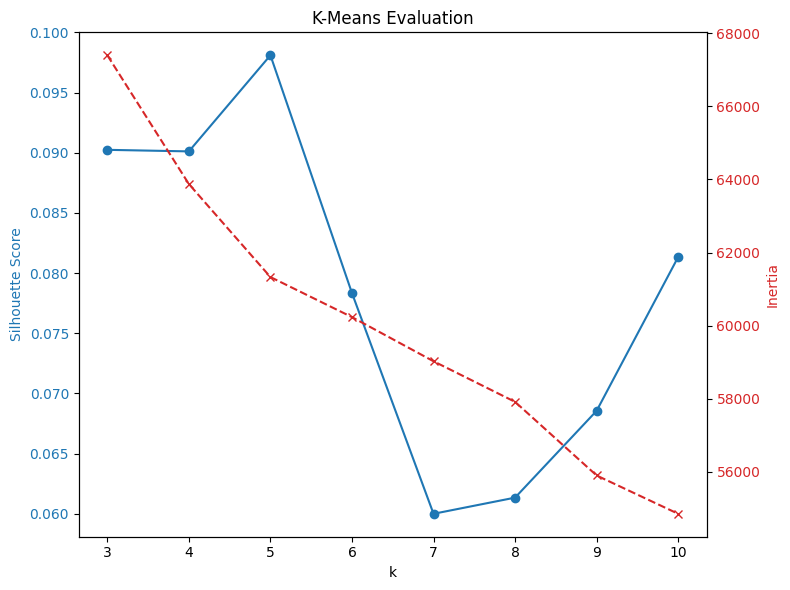

In [33]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = [col for col in df_scaled.columns]
X = df_scaled[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(3, 11)
silhouette_scores = []
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"k = {k}: Inertia = {kmeans.inertia_:.2f}, Silhouette = {silhouette_score(X_scaled, labels):.4f}")

fig, ax1 = plt.subplots(figsize=(8,6))
color = 'tab:blue'
ax1.set_xlabel('k')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(k_values, silhouette_scores, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(list(k_values))
ax1.set_title("K-Means Evaluation")

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Inertia', color=color)
ax2.plot(k_values, inertias, marker='x', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

Cluster Statistics:
           Income   Kidhome  Teenhome   Recency  MntWines  MntFruits  \
Cluster                                                                
0       -0.535192  0.351374 -0.121690  0.029607 -0.656467  -0.277523   
1       -0.706367  0.641054 -0.150783  0.018937 -0.775924  -0.526933   
2       -0.320662  0.444027  0.268952 -0.090906 -0.529509  -0.554426   
3        0.270374 -0.449812  0.722934 -0.010458  0.560484   0.070363   
4        1.059501 -0.766241 -0.711224  0.022467  0.973699   1.068875   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0              -0.472958        -0.228845         -0.293415     -0.272425   
1              -0.628602        -0.543444         -0.517964     -0.516555   
2              -0.567414        -0.558972         -0.535786     -0.566325   
3              -0.043579        -0.026760          0.041955      0.426626   
4            

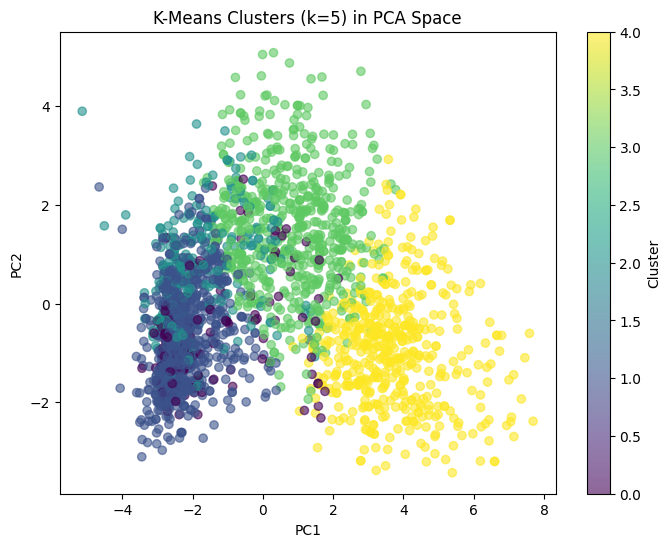

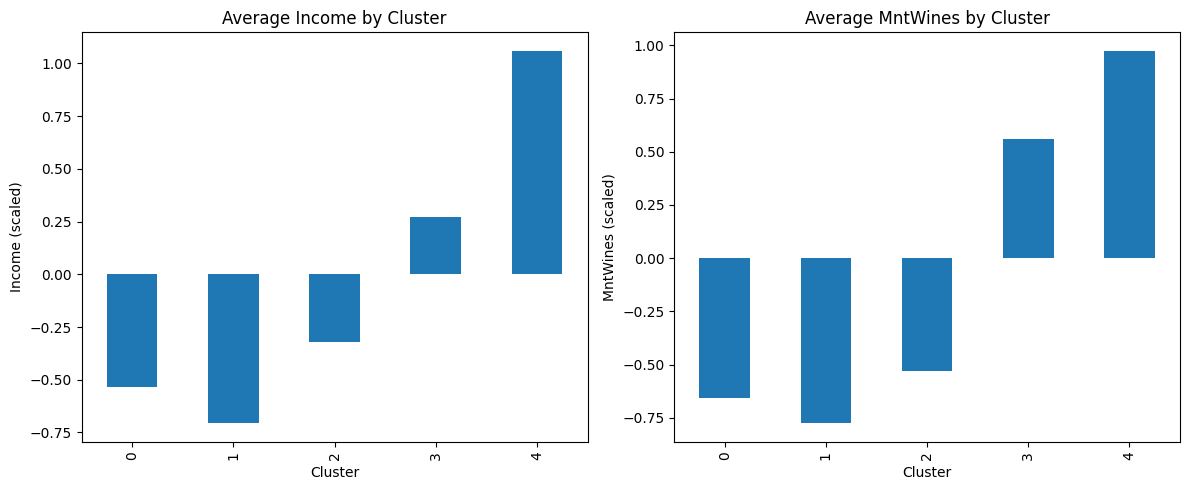

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = list(df_scaled.columns)
X = df_scaled[features]



k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

df_scaled['Cluster'] = labels

cluster_stats = df_scaled.groupby('Cluster').mean()
print("Cluster Statistics:")
print(cluster_stats)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (k=5) in PCA Space')
plt.colorbar(label='Cluster')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
income_means = df_scaled.groupby('Cluster')['Income'].mean()
wine_means = df_scaled.groupby('Cluster')['MntWines'].mean()

income_means.plot(kind='bar', ax=ax[0])
ax[0].set_title('Average Income by Cluster')
ax[0].set_ylabel('Income (scaled)')

wine_means.plot(kind='bar', ax=ax[1])
ax[1].set_title('Average MntWines by Cluster')
ax[1].set_ylabel('MntWines (scaled)')

plt.tight_layout()
plt.show()

Cluster Statistics (means):
           Income   Kidhome  Teenhome   Recency  MntWines  MntFruits  \
Cluster                                                                
0       -0.335761  0.165596 -0.113526  0.005240 -0.454080   0.011400   
1       -0.520379  0.457874  0.112077  0.006787 -0.584119  -0.497502   
2        0.692306 -0.641333 -0.028859  0.005673  0.672354   0.687466   
3        1.132017 -0.740291 -0.625506  0.003722  1.681506   0.700999   
4       -0.193478  0.193563  0.610671 -0.432682  0.233220  -0.530030   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0              -0.260982         0.044494          0.015705     -0.073065   
1              -0.564956        -0.513592         -0.500886     -0.405327   
2               0.736767         0.716119          0.658749      0.562389   
3               1.243303         0.671279          0.843199      0.624960   
4    

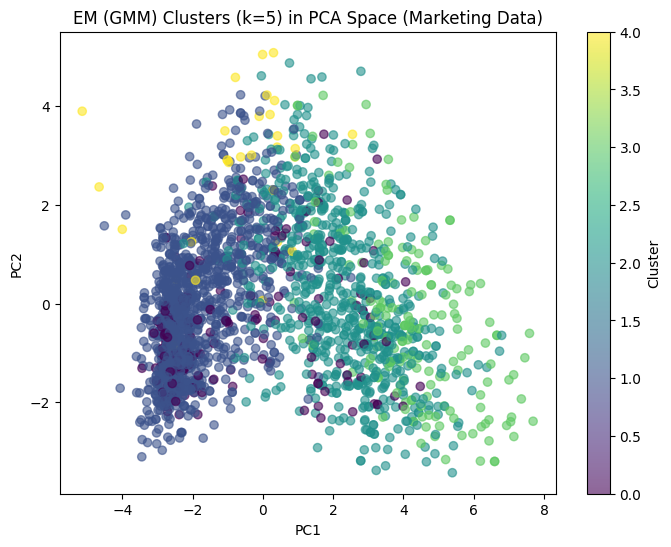

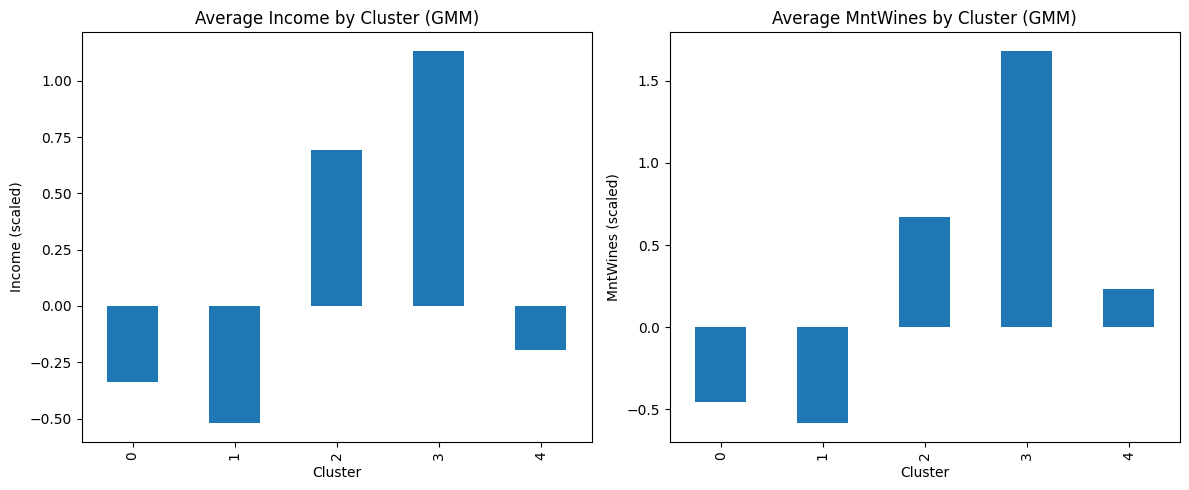

In [37]:
from sklearn.mixture import GaussianMixture

features = [col for col in marketing_df.columns]
X = marketing_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 5
gmm = GaussianMixture(n_components=k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['Cluster'] = gmm_labels

cluster_stats = df_scaled.groupby('Cluster').mean()
print("Cluster Statistics (means):")
print(cluster_stats)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'EM (GMM) Clusters (k={k}) in PCA Space (Marketing Data)')
plt.colorbar(label='Cluster')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

income_means = df_scaled.groupby('Cluster')['Income'].mean()
wine_means = df_scaled.groupby('Cluster')['MntWines'].mean()

income_means.plot(kind='bar', ax=ax[0])
ax[0].set_title('Average Income by Cluster (GMM)')
ax[0].set_ylabel('Income (scaled)')

wine_means.plot(kind='bar', ax=ax[1])
ax[1].set_title('Average MntWines by Cluster (GMM)')
ax[1].set_ylabel('MntWines (scaled)')

plt.tight_layout()
plt.show()

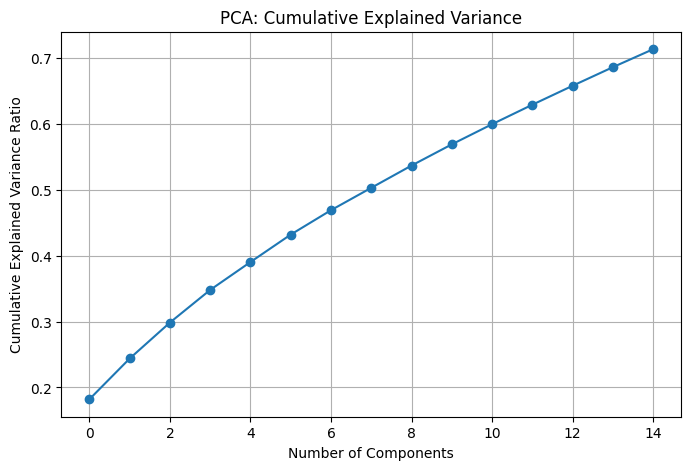

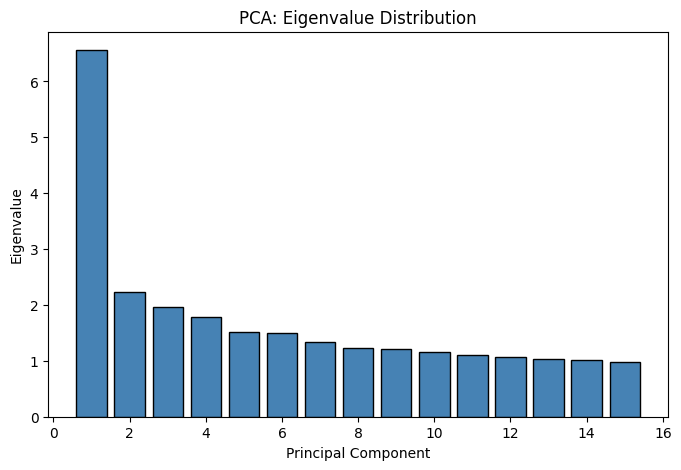

Kurtosis of each ICA component: [ 3.4379667   2.80691173 -1.18911826 -1.68886734  0.40161493 -1.21420517
 15.49343555 -1.66802089  0.27066432  1.08586054]


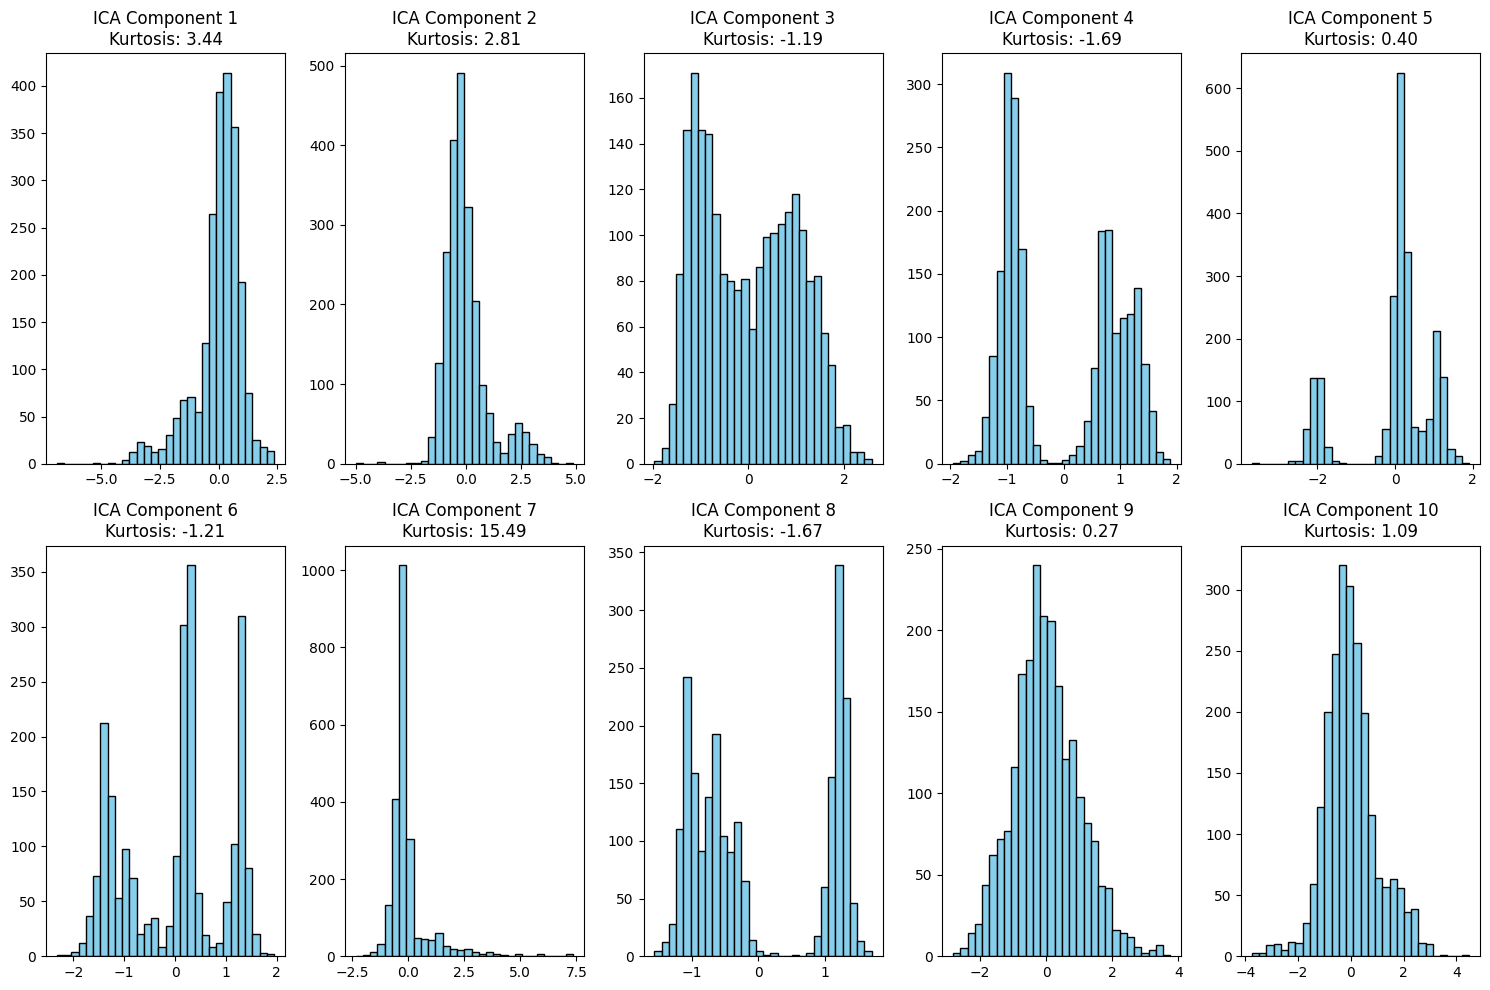

Random Projection Reconstruction Error (Frobenius norm): 239.58936484062468
Reconstruction errors from different random projections: [np.float64(243.71183558999488), np.float64(240.35440332862606), np.float64(242.49235333833116), np.float64(248.46160904529458), np.float64(249.09095982415542), np.float64(237.21996792589584), np.float64(244.1970349816785), np.float64(247.98359563274906), np.float64(242.39402340216176), np.float64(239.20204343637695)]


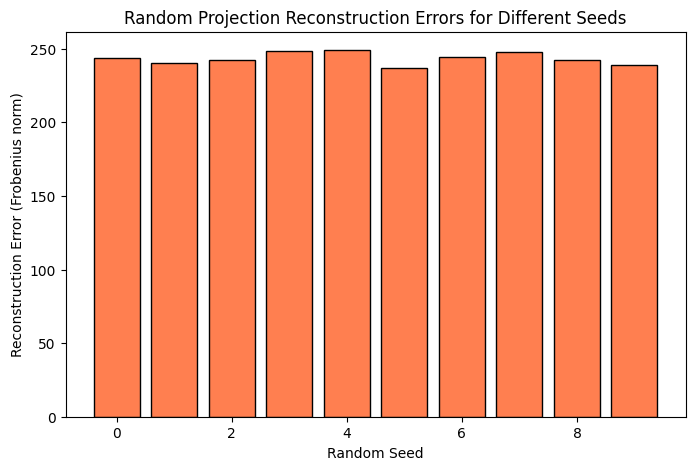

Rank of the data: 34
Average absolute correlation between features: 0.10563432190025769


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


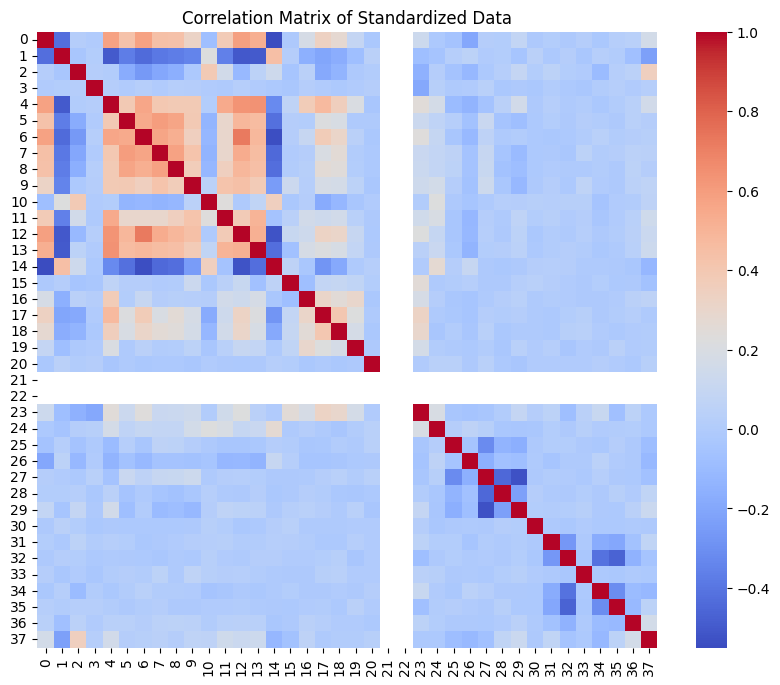

In [47]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.random_projection import GaussianRandomProjection
from scipy.stats import kurtosis

features = list(marketing_df.columns)
X = marketing_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_scaled)
eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_ratio), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA: Cumulative Explained Variance')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(range(1, 16), eigenvalues, color='steelblue', edgecolor='k')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('PCA: Eigenvalue Distribution')
plt.show()

ica = FastICA(n_components=10, random_state=42)
X_ica = ica.fit_transform(X_scaled)
ica_kurtosis = kurtosis(X_ica, fisher=True)
print("Kurtosis of each ICA component:", ica_kurtosis)

plt.figure(figsize=(15,10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.hist(X_ica[:, i], bins=30, color='skyblue', edgecolor='k')
    plt.title(f'ICA Component {i+1}\nKurtosis: {ica_kurtosis[i]:.2f}')
plt.tight_layout()
plt.show()

rp = GaussianRandomProjection(n_components=10, random_state=42)
X_rp = rp.fit_transform(X_scaled)
rp_reconstructed = np.dot(X_rp, np.linalg.pinv(rp.components_.T))
reconstruction_error = np.linalg.norm(X_scaled - rp_reconstructed, ord='fro')
print("Random Projection Reconstruction Error (Frobenius norm):", reconstruction_error)

errors = []
for seed in range(10):
    rp_temp = GaussianRandomProjection(n_components=10, random_state=seed)
    X_rp_temp = rp_temp.fit_transform(X_scaled)
    rp_rec_temp = np.dot(X_rp_temp, np.linalg.pinv(rp_temp.components_.T))
    err = np.linalg.norm(X_scaled - rp_rec_temp, ord='fro')
    errors.append(err)
print("Reconstruction errors from different random projections:", errors)

plt.figure(figsize=(8,5))
plt.bar(range(10), errors, color='coral', edgecolor='k')
plt.xlabel('Random Seed')
plt.ylabel('Reconstruction Error (Frobenius norm)')
plt.title('Random Projection Reconstruction Errors for Different Seeds')
plt.show()

# Data rank and collinearity analysis
data_rank = np.linalg.matrix_rank(X_scaled)
print("Rank of the data:", data_rank)
corr_matrix = np.corrcoef(X_scaled, rowvar=False)
avg_correlation = np.nanmean(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]))
print("Average absolute correlation between features:", avg_correlation)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of Standardized Data')
plt.show()

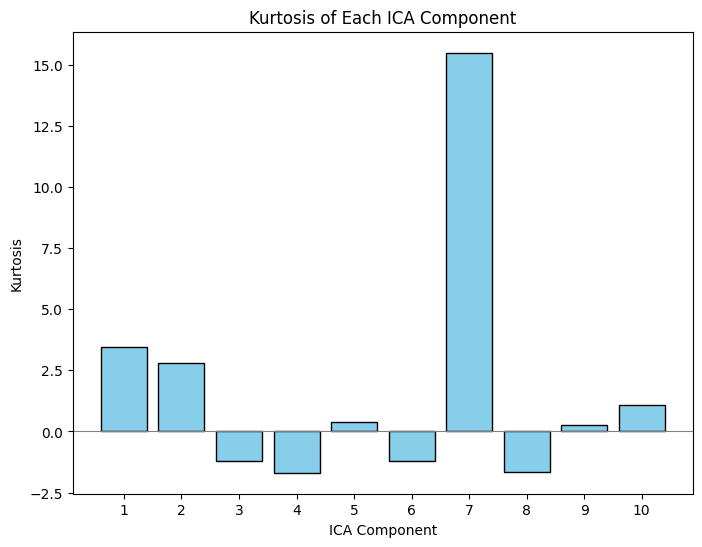

In [48]:
import matplotlib.pyplot as plt
import numpy as np

ica_kurtosis = np.array([3.4379667, 2.80691173, -1.18911826, -1.68886734, 0.40161493,
                         -1.21420517, 15.49343555, -1.66802089, 0.27066432, 1.08586054])

plt.figure(figsize=(8,6))
plt.bar(range(1, len(ica_kurtosis)+1), ica_kurtosis, color='skyblue', edgecolor='k')
plt.xlabel("ICA Component")
plt.ylabel("Kurtosis")
plt.title("Kurtosis of Each ICA Component")
plt.xticks(range(1, len(ica_kurtosis)+1))
plt.axhline(0, color='gray', linewidth=0.8)
plt.show()

In [50]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.random_projection import GaussianRandomProjection
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

features = [col for col in marketing_df.columns]
X = marketing_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


def evaluate_dr_clustering(X_data, dr_method, cluster_method, n_clusters=4):

    if dr_method == 'PCA':
        dr = PCA(n_components=10, random_state=42)
        X_reduced = dr.fit_transform(X_data)

    elif dr_method == 'ICA':
        dr = FastICA(n_components=10, random_state=42)
        X_reduced = dr.fit_transform(X_data)
    elif dr_method == 'RP':
        dr = GaussianRandomProjection(n_components=10, random_state=42)
        X_reduced = dr.fit_transform(X_data)
    else:
        raise ValueError("Unknown DR method.")

    if cluster_method == 'KMeans':
        clust = KMeans(n_clusters=n_clusters, random_state=42)
        labels = clust.fit_predict(X_reduced)
        inertia = clust.inertia_
        silhouette = silhouette_score(X_reduced, labels)
        return {
            'DR_Method': dr_method,
            'Clust_Algo': cluster_method,
            'Silhouette': silhouette,
            'Inertia': inertia,
            'LogLikelihood': None
        }
    elif cluster_method == 'EM':
        gm = GaussianMixture(n_components=n_clusters, random_state=42)
        gm.fit(X_reduced)
        labels = gm.predict(X_reduced)
        silhouette = silhouette_score(X_reduced, labels)
        log_likelihood = gm.lower_bound_
        return {
            'DR_Method': dr_method,
            'Clust_Algo': cluster_method,
            'Silhouette': silhouette,
            'Inertia': None,
            'LogLikelihood': log_likelihood
        }
    else:
        raise ValueError("Unknown clustering method.")


dr_methods = ['PCA', 'ICA', 'RP']
cluster_algos = ['KMeans', 'EM']
n_clusters = 5

results = []
for dr_m in dr_methods:
    for clust_m in cluster_algos:
        result_dict = evaluate_dr_clustering(X_scaled, dr_m, clust_m, n_clusters)
        results.append(result_dict)

df_results = pd.DataFrame(results)
print(df_results)



  DR_Method Clust_Algo  Silhouette       Inertia  LogLikelihood
0       PCA     KMeans    0.156018  27542.286461            NaN
1       PCA         EM    0.054854           NaN     -12.114742
2       ICA     KMeans    0.180059  15381.288413            NaN
3       ICA         EM    0.132597           NaN      -8.863962
4        RP     KMeans    0.122066  48115.212134            NaN
5        RP         EM    0.033484           NaN     -16.340332


In [51]:
def split_data(marketing_df, method='train_val_test', k=5, val_size=0.2, test_size=0.2):

    X = marketing_df.drop(columns=['AcceptedAny']).values
    y = marketing_df['AcceptedAny'].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if method == 'train_val_test':
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        val_size_adjusted = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size_adjusted, random_state=42, stratify=y_train_val
        )

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

        print(f"Train: {X_train_tensor.shape[0]}, Val: {X_val_tensor.shape[0]}, Test: {X_test_tensor.shape[0]}")
        return X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor

    elif method == 'cross_val':
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        folds = []

        for train_index, test_index in skf.split(X, y):
            X_train_fold, X_test_fold = X[train_index], X[test_index]
            y_train_fold, y_test_fold = y[train_index], y[test_index]

            X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
            X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).unsqueeze(1)

            folds.append((X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor))

        print(f"Train: {folds[0][0].shape[0]}, Test: {folds[0][2].shape[0]}")
        return folds


In [54]:
irrelevant_columns = ['NumDealsPurchases', 'Response']
marketing_df = marketing_df.drop(columns=irrelevant_columns)

marketing_df['AcceptedAny'] = (
    (marketing_df['AcceptedCmp1'] == 1) |
    (marketing_df['AcceptedCmp2'] == 1) |
    (marketing_df['AcceptedCmp3'] == 1) |
    (marketing_df['AcceptedCmp4'] == 1) |
    (marketing_df['AcceptedCmp5'] == 1)
).astype(int)

marketing_df.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], inplace=True)

print(marketing_df[['AcceptedAny']].value_counts())

AcceptedAny
0              1777
1               463
Name: count, dtype: int64


In [55]:
print(marketing_df[['AcceptedAny']].value_counts())
#%%
marketing_df['Education'] = marketing_df[['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD']].idxmax(axis=1)

marketing_df['Marital_Status'] = marketing_df[['Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married',
                                               'Marital_Status_Divorced', 'Marital_Status_Widow', 'Marital_Status_Alone',
                                               'Marital_Status_Other']].idxmax(axis=1)
marketing_df.drop(columns=['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD',
                           'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 'Marital_Status_Divorced',
                           'Marital_Status_Widow', 'Marital_Status_Alone', 'Marital_Status_Other'], inplace=True)

print(marketing_df[['Education', 'Marital_Status']].head())

AcceptedAny
0              1777
1               463
Name: count, dtype: int64
              Education           Marital_Status
0  Education_Graduation    Marital_Status_Single
1  Education_Graduation    Marital_Status_Single
2  Education_Graduation  Marital_Status_Together
3  Education_Graduation  Marital_Status_Together
4         Education_PhD   Marital_Status_Married


In [56]:
marketing_df['Education'] = marketing_df['Education'].str.replace('Education_', '')
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].str.replace('Marital_Status_', '')

print(marketing_df[['Education', 'Marital_Status']].head())

    Education Marital_Status
0  Graduation         Single
1  Graduation         Single
2  Graduation       Together
3  Graduation       Together
4         PhD        Married


In [57]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
marketing_df['Education'] = label_enc.fit_transform(marketing_df['Education'])
marketing_df['Marital_Status'] = label_enc.fit_transform(marketing_df['Marital_Status'])

print(marketing_df[['Education', 'Marital_Status']].value_counts())

Education  Marital_Status
2          2                 433
           5                 286
           4                 252
4          2                 192
3          2                 138
2          1                 119
4          5                 117
3          5                 106
4          4                  98
0          2                  81
3          4                  75
0          5                  57
4          1                  52
0          4                  37
3          1                  37
2          6                  35
4          6                  24
0          1                  23
1          2                  20
           4                  18
           5                  14
3          6                  12
0          6                   5
4          3                   2
2          0                   1
1          6                   1
           1                   1
2          3                   1
3          0                   1
           3     

In [58]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')


Train: 1344, Val: 448, Test: 448


In [59]:
def apply_dimensionality_reduction(X_train, X_val, X_test, method, n_components=10):

    if method == 'none':
        # No DR, just return original data
        return X_train, X_val, X_test
    elif method == 'pca':
        dr = PCA(n_components=n_components, random_state=42)
    elif method == 'ica':
        dr = FastICA(n_components=n_components, random_state=42)
    elif method == 'rp':
        dr = GaussianRandomProjection(n_components=n_components, random_state=42)
    else:
        raise ValueError("Unknown DR method")

    dr.fit(X_train)
    X_train_dr = dr.transform(X_train)
    X_val_dr = dr.transform(X_val)
    X_test_dr = dr.transform(X_test)

    return X_train_dr, X_val_dr, X_test_dr

In [60]:
def run_experiment_with_dr(dr_method, num_epochs=300, lr=0.001):

    X_train_dr, X_val_dr, X_test_dr = apply_dimensionality_reduction(X_train, X_val, X_test, dr_method, n_components=10)

    train_data = torch.utils.data.TensorDataset(
        torch.tensor(X_train_dr, dtype=torch.float32),
        y_train
    )
    val_data = torch.utils.data.TensorDataset(
        torch.tensor(X_val_dr, dtype=torch.float32),
        y_val
    )
    test_data = torch.utils.data.TensorDataset(
        torch.tensor(X_test_dr, dtype=torch.float32),
        y_test
    )

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(val_data,   batch_size=64, shuffle=False)
    test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=64, shuffle=False)

    input_dim = X_train_dr.shape[1]
    model = SimpleNN(activation_function=nn.ReLU())
    model.net[0] = nn.Linear(input_dim, 64)

    start_time = time.time()
    train_losses, val_losses, test_losses = train_model(model, train_loader, val_loader, test_loader,
                                                        num_epochs=num_epochs, lr=lr)
    end_time = time.time()
    train_time = end_time - start_time

    final_test_loss = test_losses[-1]
    return final_test_loss, train_time

In [61]:
class SimpleNN(nn.Module):
    def __init__(self, activation_function=nn.ReLU()):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            activation_function,
            nn.Linear(64, 32),
            activation_function,
            nn.Linear(32, 16),
            activation_function,
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [63]:
num_epochs = 300
batch_size = 64
learning_rate = 0.001

In [64]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)




In [65]:

val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [66]:
def train_model(model, train_loader, val_loader, test_loader, num_epochs=200, lr=0.001):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    criterion = nn.BCELoss()
    train_losses, val_losses, test_losses = [], [], []
    best_model = None
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        train_losses.append(epoch_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                test_loss += loss.item()
        test_loss /= len(test_loader)
        test_losses.append(test_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()

        if best_model:
            torch.save(best_model, "best_model.pth")

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}")

    plt.figure(figsize=(10, 5))
    plt.title('Learning Curve - Neural Network: Loss/Error Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
    plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
    plt.legend()
    # plt.savefig("loss_all_full_nn_300epoch_400data.png")
    plt.show()



    return train_losses, val_losses, test_losses


<ipython-input-60-39a7e768ad10>:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_train_dr, dtype=torch.float32),
<ipython-input-60-39a7e768ad10>:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_val_dr, dtype=torch.float32),
<ipython-input-60-39a7e768ad10>:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_test_dr, dtype=torch.float32),


Epoch 1/300 - Train Loss: 0.7324, Val Loss: 0.7197, Test Loss: 0.7186
Epoch 2/300 - Train Loss: 0.7045, Val Loss: 0.6898, Test Loss: 0.6888
Epoch 3/300 - Train Loss: 0.6755, Val Loss: 0.6618, Test Loss: 0.6609
Epoch 4/300 - Train Loss: 0.6490, Val Loss: 0.6375, Test Loss: 0.6367
Epoch 5/300 - Train Loss: 0.6259, Val Loss: 0.6160, Test Loss: 0.6154
Epoch 6/300 - Train Loss: 0.6052, Val Loss: 0.5975, Test Loss: 0.5970
Epoch 7/300 - Train Loss: 0.5879, Val Loss: 0.5800, Test Loss: 0.5798
Epoch 8/300 - Train Loss: 0.5715, Val Loss: 0.5662, Test Loss: 0.5662
Epoch 9/300 - Train Loss: 0.5585, Val Loss: 0.5532, Test Loss: 0.5535
Epoch 10/300 - Train Loss: 0.5465, Val Loss: 0.5425, Test Loss: 0.5431
Epoch 11/300 - Train Loss: 0.5368, Val Loss: 0.5329, Test Loss: 0.5339
Epoch 12/300 - Train Loss: 0.5281, Val Loss: 0.5250, Test Loss: 0.5264
Epoch 13/300 - Train Loss: 0.5211, Val Loss: 0.5180, Test Loss: 0.5198
Epoch 14/300 - Train Loss: 0.5148, Val Loss: 0.5124, Test Loss: 0.5145
Epoch 15/300 - 

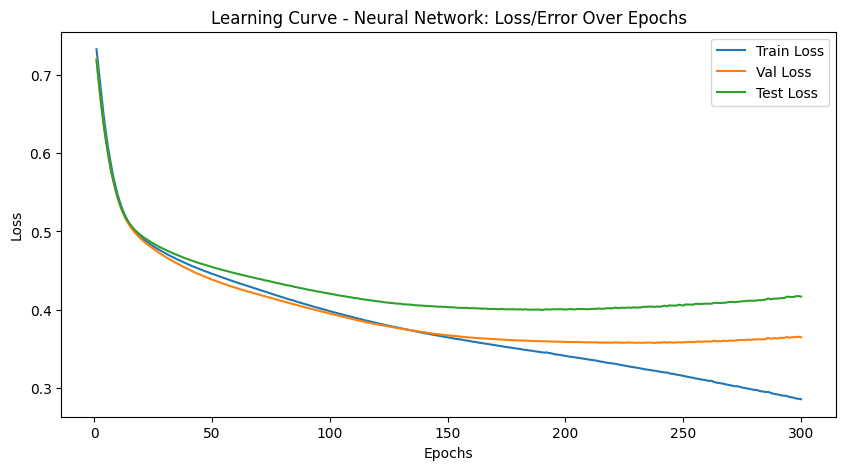

DR=none: Final Test Loss=0.4168, Training Time=36.81s
Epoch 1/300 - Train Loss: 0.7503, Val Loss: 0.7343, Test Loss: 0.7343
Epoch 2/300 - Train Loss: 0.7200, Val Loss: 0.7031, Test Loss: 0.7027
Epoch 3/300 - Train Loss: 0.6900, Val Loss: 0.6751, Test Loss: 0.6745
Epoch 4/300 - Train Loss: 0.6635, Val Loss: 0.6516, Test Loss: 0.6509
Epoch 5/300 - Train Loss: 0.6415, Val Loss: 0.6303, Test Loss: 0.6296
Epoch 6/300 - Train Loss: 0.6217, Val Loss: 0.6123, Test Loss: 0.6115
Epoch 7/300 - Train Loss: 0.6047, Val Loss: 0.5964, Test Loss: 0.5955
Epoch 8/300 - Train Loss: 0.5899, Val Loss: 0.5820, Test Loss: 0.5811
Epoch 9/300 - Train Loss: 0.5763, Val Loss: 0.5699, Test Loss: 0.5689
Epoch 10/300 - Train Loss: 0.5650, Val Loss: 0.5584, Test Loss: 0.5575
Epoch 11/300 - Train Loss: 0.5545, Val Loss: 0.5484, Test Loss: 0.5475
Epoch 12/300 - Train Loss: 0.5453, Val Loss: 0.5396, Test Loss: 0.5388
Epoch 13/300 - Train Loss: 0.5370, Val Loss: 0.5320, Test Loss: 0.5312
Epoch 14/300 - Train Loss: 0.530

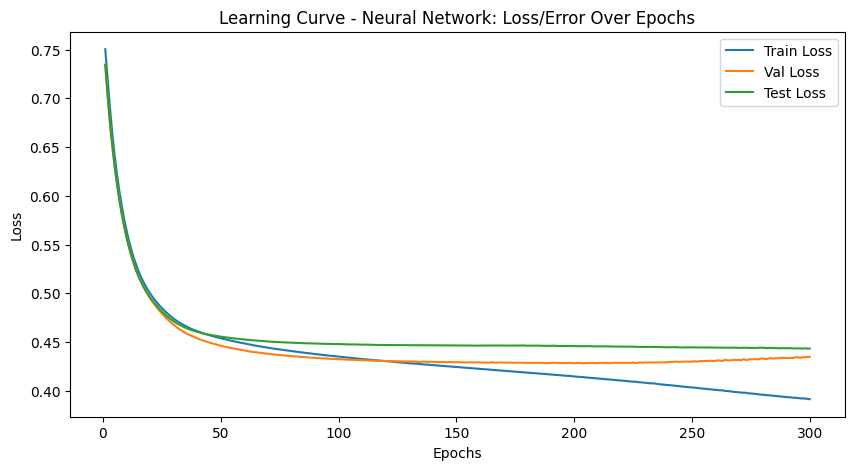

DR=pca: Final Test Loss=0.4434, Training Time=22.21s
Epoch 1/300 - Train Loss: 0.7477, Val Loss: 0.7354, Test Loss: 0.7361
Epoch 2/300 - Train Loss: 0.7225, Val Loss: 0.7082, Test Loss: 0.7088
Epoch 3/300 - Train Loss: 0.6963, Val Loss: 0.6836, Test Loss: 0.6842
Epoch 4/300 - Train Loss: 0.6731, Val Loss: 0.6622, Test Loss: 0.6628
Epoch 5/300 - Train Loss: 0.6528, Val Loss: 0.6433, Test Loss: 0.6440
Epoch 6/300 - Train Loss: 0.6350, Val Loss: 0.6265, Test Loss: 0.6271
Epoch 7/300 - Train Loss: 0.6191, Val Loss: 0.6118, Test Loss: 0.6124
Epoch 8/300 - Train Loss: 0.6051, Val Loss: 0.5985, Test Loss: 0.5991
Epoch 9/300 - Train Loss: 0.5925, Val Loss: 0.5871, Test Loss: 0.5876
Epoch 10/300 - Train Loss: 0.5815, Val Loss: 0.5768, Test Loss: 0.5772
Epoch 11/300 - Train Loss: 0.5719, Val Loss: 0.5673, Test Loss: 0.5676
Epoch 12/300 - Train Loss: 0.5629, Val Loss: 0.5594, Test Loss: 0.5597
Epoch 13/300 - Train Loss: 0.5555, Val Loss: 0.5520, Test Loss: 0.5522
Epoch 14/300 - Train Loss: 0.5486

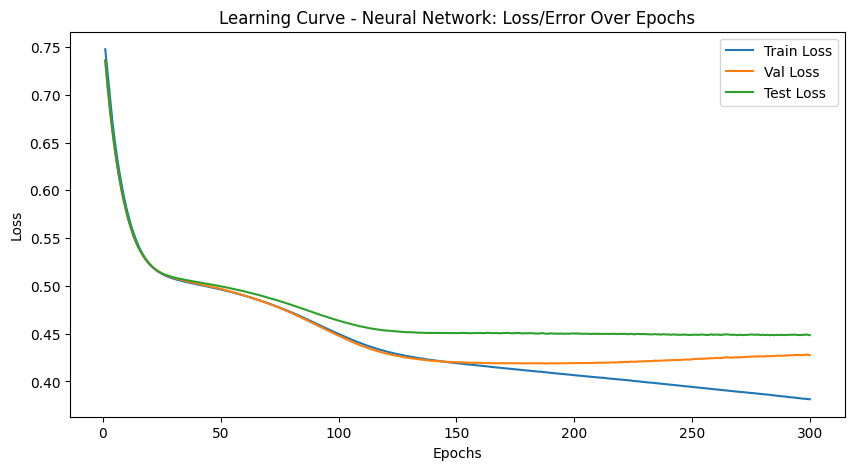

DR=ica: Final Test Loss=0.4485, Training Time=21.10s
Epoch 1/300 - Train Loss: 0.7559, Val Loss: 0.7431, Test Loss: 0.7418
Epoch 2/300 - Train Loss: 0.7237, Val Loss: 0.7072, Test Loss: 0.7060
Epoch 3/300 - Train Loss: 0.6897, Val Loss: 0.6759, Test Loss: 0.6747
Epoch 4/300 - Train Loss: 0.6601, Val Loss: 0.6489, Test Loss: 0.6476
Epoch 5/300 - Train Loss: 0.6345, Val Loss: 0.6252, Test Loss: 0.6238
Epoch 6/300 - Train Loss: 0.6122, Val Loss: 0.6035, Test Loss: 0.6021
Epoch 7/300 - Train Loss: 0.5918, Val Loss: 0.5853, Test Loss: 0.5840
Epoch 8/300 - Train Loss: 0.5745, Val Loss: 0.5688, Test Loss: 0.5676
Epoch 9/300 - Train Loss: 0.5590, Val Loss: 0.5547, Test Loss: 0.5537
Epoch 10/300 - Train Loss: 0.5456, Val Loss: 0.5421, Test Loss: 0.5414
Epoch 11/300 - Train Loss: 0.5340, Val Loss: 0.5311, Test Loss: 0.5309
Epoch 12/300 - Train Loss: 0.5240, Val Loss: 0.5217, Test Loss: 0.5221
Epoch 13/300 - Train Loss: 0.5153, Val Loss: 0.5135, Test Loss: 0.5147
Epoch 14/300 - Train Loss: 0.5080

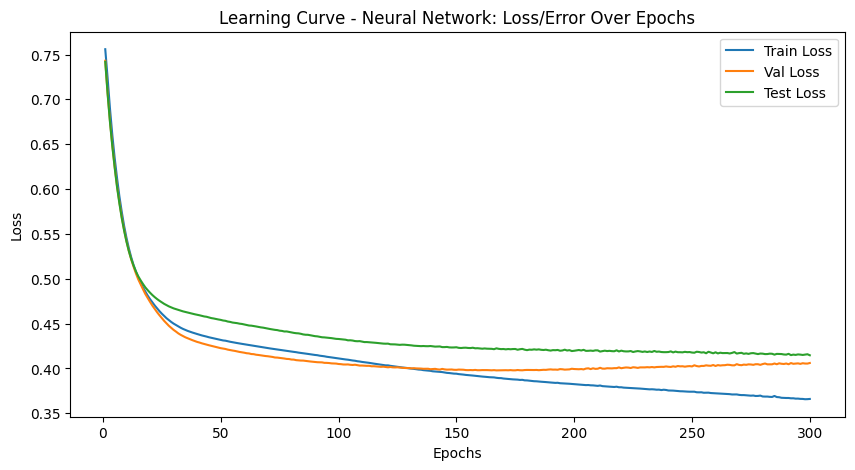

DR=rp: Final Test Loss=0.4147, Training Time=19.94s


In [67]:
dr_methods = ['none', 'pca', 'ica', 'rp']
final_test_losses = []
training_times = []

for method in dr_methods:
    test_loss, t_time = run_experiment_with_dr(method, num_epochs=300, lr=0.001)
    final_test_losses.append(test_loss)
    training_times.append(t_time)
    print(f"DR={method}: Final Test Loss={test_loss:.4f}, Training Time={t_time:.2f}s")


In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.bar(dr_methods, final_test_losses, color='skyblue', edgecolor='k')
plt.title("Final Test Loss by DR Method")
plt.xlabel("DR Method")
plt.ylabel("Test Loss")

plt.subplot(1,2,2)
plt.bar(dr_methods, training_times, color='coral', edgecolor='k')
plt.title("Training Time by DR Method")
plt.xlabel("DR Method")
plt.ylabel("Seconds")

plt.tight_layout()
plt.show()

Epoch 1/300 - Train Loss: 0.7707, Val Loss: 0.7554, Test Loss: 0.7557
Epoch 2/300 - Train Loss: 0.7393, Val Loss: 0.7211, Test Loss: 0.7217
Epoch 3/300 - Train Loss: 0.7073, Val Loss: 0.6905, Test Loss: 0.6914
Epoch 4/300 - Train Loss: 0.6789, Val Loss: 0.6653, Test Loss: 0.6663
Epoch 5/300 - Train Loss: 0.6555, Val Loss: 0.6427, Test Loss: 0.6440
Epoch 6/300 - Train Loss: 0.6347, Val Loss: 0.6237, Test Loss: 0.6251
Epoch 7/300 - Train Loss: 0.6168, Val Loss: 0.6069, Test Loss: 0.6084
Epoch 8/300 - Train Loss: 0.6008, Val Loss: 0.5923, Test Loss: 0.5939
Epoch 9/300 - Train Loss: 0.5870, Val Loss: 0.5787, Test Loss: 0.5804
Epoch 10/300 - Train Loss: 0.5741, Val Loss: 0.5672, Test Loss: 0.5692
Epoch 11/300 - Train Loss: 0.5633, Val Loss: 0.5561, Test Loss: 0.5583
Epoch 12/300 - Train Loss: 0.5531, Val Loss: 0.5465, Test Loss: 0.5490
Epoch 13/300 - Train Loss: 0.5441, Val Loss: 0.5379, Test Loss: 0.5407
Epoch 14/300 - Train Loss: 0.5362, Val Loss: 0.5299, Test Loss: 0.5330
Epoch 15/300 - 

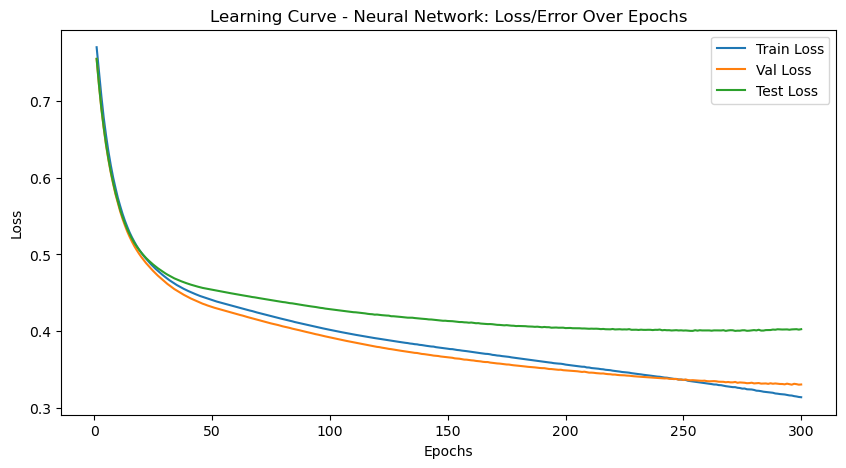

Training Time: 17.19


In [ ]:
model = SimpleNN(activation_function=nn.ReLU())
start_time = time.time()
train_losses, val_losses, test_losses = train_model(model, train_loader, val_loader, test_loader, num_epochs=num_epochs, lr=0.001)
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f}")

Train: 1344, Val: 448, Test: 448
Epoch 1/300 - Train Loss: 0.7409, Val Loss: 0.7282, Test Loss: 0.7270
Epoch 2/300 - Train Loss: 0.7143, Val Loss: 0.7001, Test Loss: 0.6988
Epoch 3/300 - Train Loss: 0.6869, Val Loss: 0.6732, Test Loss: 0.6718
Epoch 4/300 - Train Loss: 0.6615, Val Loss: 0.6495, Test Loss: 0.6481
Epoch 5/300 - Train Loss: 0.6390, Val Loss: 0.6285, Test Loss: 0.6271
Epoch 6/300 - Train Loss: 0.6189, Val Loss: 0.6097, Test Loss: 0.6084
Epoch 7/300 - Train Loss: 0.6010, Val Loss: 0.5927, Test Loss: 0.5913
Epoch 8/300 - Train Loss: 0.5850, Val Loss: 0.5771, Test Loss: 0.5757
Epoch 9/300 - Train Loss: 0.5704, Val Loss: 0.5637, Test Loss: 0.5622
Epoch 10/300 - Train Loss: 0.5577, Val Loss: 0.5518, Test Loss: 0.5502
Epoch 11/300 - Train Loss: 0.5465, Val Loss: 0.5409, Test Loss: 0.5393
Epoch 12/300 - Train Loss: 0.5367, Val Loss: 0.5313, Test Loss: 0.5298
Epoch 13/300 - Train Loss: 0.5279, Val Loss: 0.5232, Test Loss: 0.5217
Epoch 14/300 - Train Loss: 0.5205, Val Loss: 0.5161, 

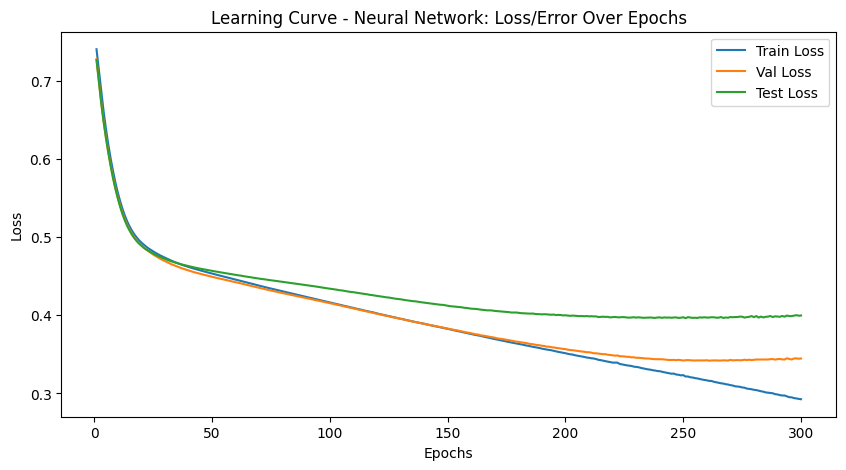

Train: 1344, Val: 448, Test: 448
Epoch 1/300 - Train Loss: 0.6495, Val Loss: 0.6402, Test Loss: 0.6411
Epoch 2/300 - Train Loss: 0.6329, Val Loss: 0.6233, Test Loss: 0.6242
Epoch 3/300 - Train Loss: 0.6167, Val Loss: 0.6078, Test Loss: 0.6089
Epoch 4/300 - Train Loss: 0.6023, Val Loss: 0.5947, Test Loss: 0.5958
Epoch 5/300 - Train Loss: 0.5900, Val Loss: 0.5836, Test Loss: 0.5847
Epoch 6/300 - Train Loss: 0.5795, Val Loss: 0.5736, Test Loss: 0.5749
Epoch 7/300 - Train Loss: 0.5701, Val Loss: 0.5651, Test Loss: 0.5665
Epoch 8/300 - Train Loss: 0.5619, Val Loss: 0.5575, Test Loss: 0.5590
Epoch 9/300 - Train Loss: 0.5547, Val Loss: 0.5506, Test Loss: 0.5522
Epoch 10/300 - Train Loss: 0.5481, Val Loss: 0.5447, Test Loss: 0.5463
Epoch 11/300 - Train Loss: 0.5425, Val Loss: 0.5389, Test Loss: 0.5407
Epoch 12/300 - Train Loss: 0.5371, Val Loss: 0.5340, Test Loss: 0.5359
Epoch 13/300 - Train Loss: 0.5324, Val Loss: 0.5296, Test Loss: 0.5315
Epoch 14/300 - Train Loss: 0.5280, Val Loss: 0.5255, 

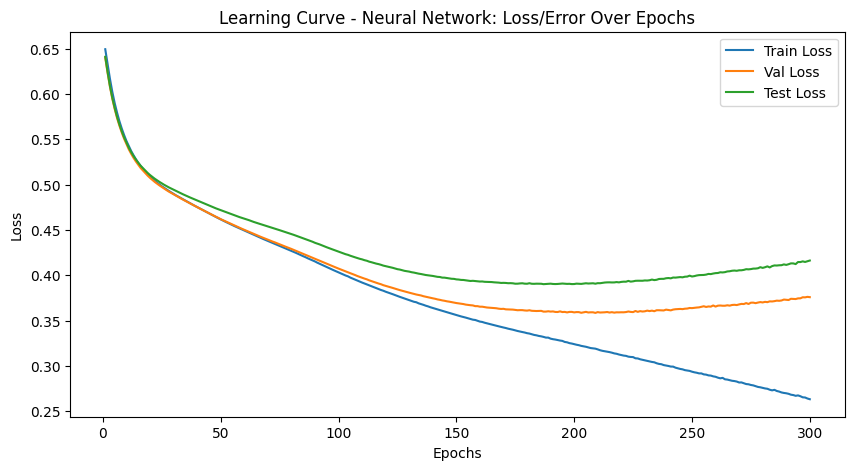

Baseline: {'Final Test Loss': 0.4168, 'Training Time (s)': 36.81}
KMeans Features: {'Final Test Loss': 0.39979402082307, 'Training Time (s)': 28.167073965072632}
EM Features: {'Final Test Loss': 0.4161899515560695, 'Training Time (s)': 20.386868000030518}


In [70]:
import numpy as np
import pandas as pd
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# excluding 'AcceptedAny'
orig_features = [col for col in marketing_df.columns if col != 'AcceptedAny']
X_orig = marketing_df[orig_features].values
y_orig = marketing_df['AcceptedAny'].values

scaler = StandardScaler()
X_orig_scaled = scaler.fit_transform(X_orig)

def add_cluster_features(X, method, n_clusters, random_state=42):
    if method == 'kmeans':
        clust = KMeans(n_clusters=n_clusters, random_state=random_state)
        labels = clust.fit_predict(X)
    elif method == 'em':
        gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
        labels = gm.fit_predict(X)
    else:
        raise ValueError("Unknown clustering method")
    encoder = OneHotEncoder(sparse_output=False)
    labels_oh = encoder.fit_transform(labels.reshape(-1, 1))
    X_new = np.hstack([X, labels_oh])
    return X_new

def run_nn_with_clusters(X, y, clustering_method, n_clusters, num_epochs=300, lr=0.001):
    X_aug = add_cluster_features(X, clustering_method, n_clusters, random_state=42)

    new_feature_names = orig_features + [f"{clustering_method.upper()}_{i}" for i in range(n_clusters)]
    df_new = pd.DataFrame(X_aug, columns=new_feature_names)
    df_new['AcceptedAny'] = y

    X_train, y_train, X_val, y_val, X_test, y_test = split_data(df_new, method='train_val_test')

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

    input_dim = X_train.shape[1]
    model = SimpleNN(activation_function=nn.ReLU())
    model.net[0] = nn.Linear(input_dim, 64)

    start_time = time.time()
    train_losses, val_losses, test_losses = train_model(model, train_loader, val_loader, test_loader,
                                                         num_epochs=num_epochs, lr=lr)
    end_time = time.time()
    training_time = end_time - start_time
    final_test_loss = test_losses[-1]
    return final_test_loss, training_time

baseline_results = {'Final Test Loss': 0.4168, 'Training Time (s)': 36.81}

test_loss_kmeans, time_kmeans = run_nn_with_clusters(X_orig_scaled, y_orig, 'kmeans', n_clusters=5, num_epochs=300, lr=0.001)

test_loss_em, time_em = run_nn_with_clusters(X_orig_scaled, y_orig, 'em', n_clusters=4, num_epochs=300, lr=0.001)

print("Baseline:", baseline_results)
print("KMeans Features:", {"Final Test Loss": test_loss_kmeans, "Training Time (s)": time_kmeans})
print("EM Features:", {"Final Test Loss": test_loss_em, "Training Time (s)": time_em})